# TSCV 多折交叉验证评估

扫描 `model/TSCV/` 目录，汇总所有已完成的 TSCV 实验结果，筛选最优模型。

评分指标: `cv_score = mean_sharpe - std_sharpe`

In [33]:
1

1

In [36]:
import os, sys, json, glob
import pandas as pd
import numpy as np

sys.path.insert(0, '../code/src')
import warnings
warnings.filterwarnings('ignore')

TSCV_DIR = "../model/TSCV"

## 1. 加载 TSCV 结果

In [37]:
rows = []
for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
    model_type = os.path.basename(os.path.normpath(mt_dir))
    parts = model_type.split("_")
    mt_short = parts[1] if len(parts) >= 2 else model_type

    for exp_dir in sorted(glob.glob(f"{mt_dir}exp_*/")):
        result_file = os.path.join(exp_dir, "tscv_results.json")
        config_file = os.path.join(exp_dir, "config.json")
        if not os.path.exists(result_file):
            continue
        with open(result_file) as f:
            r = json.load(f)
        if not r.get("success"):
            continue

        exp_idx = int(os.path.basename(os.path.normpath(exp_dir)).split("_")[1])
        folds_done = sum(1 for d in sorted(glob.glob(f"{exp_dir}fold_*/"))
                        if os.path.exists(os.path.join(d, "epoch_scores.txt")))
        folds_total = len(r.get("fold_sharpe", []))
        params = r.get("params", {})

        fold_sharpe = r.get("fold_sharpe", [])
        fold_win_rate = r.get("fold_win_rate", [])
        fold_sortino = r.get("fold_sortino", [])
        row = {
            "model_type": mt_short,
            "exp_idx": exp_idx,
            "cv_score": r.get("cv_score", r.get("sharpe", 0)),
            "mean_sharpe": r.get("mean_sharpe", 0),
            "std_sharpe": r.get("std_sharpe", 0),
            "mean_calmar": r.get("mean_calmar", 0),
            "mean_max_dd": r.get("mean_max_dd", 0),
            "mean_sortino": r.get("mean_sortino", 0),
            "mean_win_rate": r.get("mean_win_rate", 0),
            "fold_3_sharpe": fold_sharpe[3] if len(fold_sharpe) >= 4 else 0,
            "fold_3_win_rate": fold_win_rate[3] if len(fold_win_rate) >= 4 else 0,
            "fold_3_sortino": fold_sortino[3] if len(fold_sortino) >= 4 else 0,
            "folds_done": folds_done,
            "folds_total": folds_total,
            "lr": params.get("learning_rate", 0),
            "d_model": params.get("d_model", 0),
            "dropout": params.get("dropout", 0),
            "num_layers": params.get("num_layers", 0),
            "kernel_size": params.get("kernel_size", 0),
        }
        rows.append(row)

df = pd.DataFrame(rows) if rows else pd.DataFrame()
print(f"共加载 {len(df)} 个实验")
display(df["model_type"].value_counts())
if len(df) > 0:
    display(df[['model_type', 'exp_idx', 'cv_score', 'mean_sharpe', 'std_sharpe',
                'mean_max_dd', 'mean_sortino', 'mean_win_rate',
                'folds_done', 'folds_total']].sort_values(by=['cv_score'], ascending=[False]).head())

共加载 109 个实验


model_type
tcn        60
dlinear    29
gru        20
Name: count, dtype: int64

,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_max_dd,mean_sortino,mean_win_rate,folds_done,folds_total
83,tcn,43,2.532075,2.903925,0.371850,7.801375,4.727075,0.726925,4,4
8,dlinear,17,2.378302,2.412075,0.033773,8.811650,3.867275,0.541350,4,4
61,tcn,22,2.323376,2.419500,0.096124,10.307775,3.964000,0.685550,4,4
14,dlinear,22,2.204820,2.437150,0.232330,9.092275,3.851350,0.557025,4,4
99,tcn,5,2.186520,2.375500,0.188980,6.898525,3.981225,0.759000,4,4


## 2. 实验综合排名


### 2.1 按 CV Score 排名

按 `cv_score = mean_sharpe - std_sharpe` 排序。


,model_type,exp_idx,cv_score,mean_sharpe,std_sharpe,mean_calmar,mean_max_dd,mean_sortino,mean_win_rate,fold_3_sharpe,fold_3_win_rate,fold_3_sortino,folds_done,folds_total,lr,d_model,dropout,num_layers,kernel_size,rank
0,tcn,43,2.532075,2.903925,0.371850,12.518800,7.801375,4.727075,0.726925,2.500800,0.613300,4.791000,4,4,0.000063,64,0.106075,4,3,1
1,dlinear,17,2.378302,2.412075,0.033773,8.936900,8.811650,3.867275,0.541350,2.385300,0.566000,3.281300,4,4,0.000415,128,0.183346,1,25,2
2,tcn,22,2.323376,2.419500,0.096124,7.720150,10.307775,3.964000,0.685550,2.449900,0.581400,4.351600,4,4,0.000119,64,0.196560,3,3,3
3,tcn,5,2.186520,2.375500,0.188980,8.232575,6.898525,3.981225,0.759000,2.349300,0.569200,3.890900,4,4,0.000064,128,0.178518,3,3,4
4,gru,16,2.175156,2.936525,0.761369,10.029800,7.032175,4.767350,0.758800,1.715700,0.487200,3.048700,4,4,0.000210,64,0.174564,2,0,5
5,gru,14,2.074148,2.482125,0.407977,7.727025,9.213700,4.069300,0.716925,2.302300,0.573800,4.133600,4,4,0.000291,64,0.159723,2,0,6
6,tcn,54,2.068989,2.508050,0.439061,9.755700,6.486525,3.780875,0.679300,2.688900,0.431400,4.106000,4,4,0.000054,128,0.148538,4,3,7
7,tcn,49,1.990824,2.314775,0.323951,6.853900,7.972425,3.318675,0.739450,2.224000,0.589700,3.656100,4,4,0.000072,128,0.132334,4,3,8
8,tcn,28,1.978001,2.265150,0.287149,6.719700,10.186400,3.984975,0.748825,2.239900,0.437500,4.185900,4,4,0.000144,64,0.167211,2,3,9
9,tcn,45,1.929271,2.477575,0.548304,7.679000,7.684250,3.782125,0.723675,2.538500,0.513500,4.673100,4,4,0.000065,64,0.124299,4,3,10


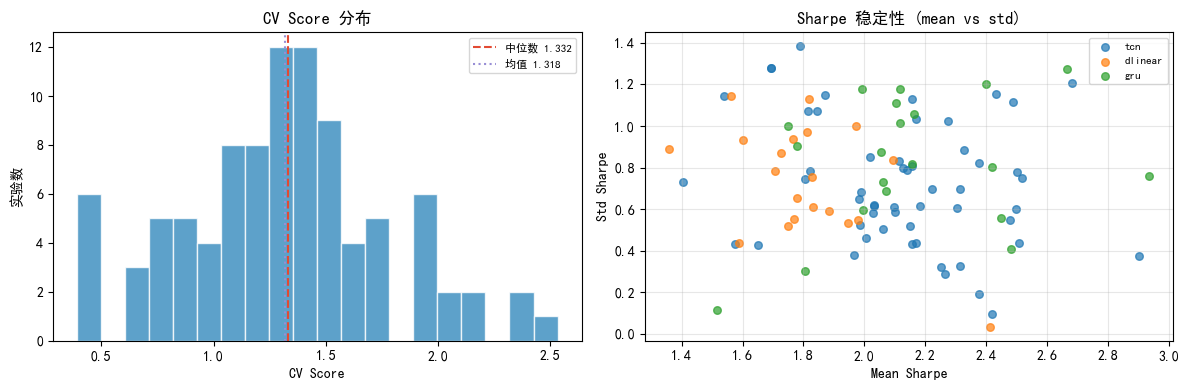

In [4]:
if len(df) > 0:
    ranked = df.sort_values('cv_score', ascending=False).reset_index(drop=True)
    ranked['rank'] = range(1, len(ranked) + 1)
    cols = ['rank', 'model_type', 'exp_idx', 'cv_score',
            'mean_sharpe', 'std_sharpe', 'mean_max_dd', 'mean_sortino', 'mean_win_rate']

    # 分位数着色排名表
    def _highlight(val, col_name, table):
        higher_better = ('cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate')
        lower_better = ('std_sharpe', 'mean_max_dd')
        if col_name in higher_better:
            if val >= table[col_name].quantile(0.8):
                return 'background-color: #006837; color: white'
            elif val >= table[col_name].quantile(0.6):
                return 'background-color: #2aa054; color: white'
            elif val >= table[col_name].quantile(0.4):
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        elif col_name in lower_better:
            if val <= table[col_name].quantile(0.2):
                return 'background-color: #006837; color: white'
            elif val <= table[col_name].quantile(0.4):
                return 'background-color: #2aa054; color: white'
            elif val <= table[col_name].quantile(0.6):
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        return ''
    styled = ranked.style.map(lambda v: _highlight(v, 'cv_score', ranked), subset=['cv_score'])
    styled = styled.map(lambda v: _highlight(v, 'std_sharpe', ranked), subset=['std_sharpe'])
    styled = styled.map(lambda v: _highlight(v, 'mean_max_dd', ranked), subset=['mean_max_dd'])
    styled = styled.map(lambda v: _highlight(v, 'mean_sharpe', ranked), subset=['mean_sharpe'])
    styled = styled.map(lambda v: _highlight(v, 'mean_sortino', ranked), subset=['mean_sortino'])
    styled = styled.map(lambda v: _highlight(v, 'mean_win_rate', ranked), subset=['mean_win_rate'])
    display(styled)

    # CV Score 分布直方图
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.hist(ranked['cv_score'], bins=20, color='#348ABD', edgecolor='white', alpha=0.8)
    ax.axvline(ranked['cv_score'].median(), color='#E24A33', linestyle='--', label=f"中位数 {ranked['cv_score'].median():.3f}")
    ax.axvline(ranked['cv_score'].mean(), color='#988ED5', linestyle=':', label=f"均值 {ranked['cv_score'].mean():.3f}")
    ax.set_xlabel('CV Score')
    ax.set_ylabel('实验数')
    ax.set_title('CV Score 分布')
    ax.legend(fontsize=8)

    ax = axes[1]
    for mt in ranked['model_type'].unique():
        sub = ranked[ranked['model_type'] == mt]
        ax.scatter(sub['mean_sharpe'], sub['std_sharpe'], label=mt, s=30, alpha=0.7)
    ax.set_xlabel('Mean Sharpe')
    ax.set_ylabel('Std Sharpe')
    ax.set_title('Sharpe 稳定性 (mean vs std)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
else:
    print("暂无完成的 TSCV 结果")

### 2.2 按综合评分排名

对每个指标计算分位数评分（0-1），加权求和得到综合评分。
越高越好的指标: cv_score, mean_sharpe, mean_sortino, mean_win_rate
越低越好的指标: std_sharpe, mean_max_dd


,rank,model_type,exp_idx,composite_score,q_cv_score,q_mean_sharpe,q_mean_sortino,q_mean_win_rate,q_std_sharpe,q_mean_max_dd,cv_score,mean_sharpe,mean_sortino,mean_win_rate,std_sharpe,mean_max_dd
0,1,tcn,5,0.911348,0.968085,0.808511,0.914894,0.851064,0.957447,0.968085,2.186520,2.375500,3.981225,0.759000,0.188980,6.898525
1,2,tcn,43,0.895390,1.000000,0.989362,0.978723,0.638298,0.904255,0.861702,2.532075,2.903925,4.727075,0.726925,0.371850,7.801375
2,3,gru,16,0.867021,0.957447,1.000000,0.989362,0.840426,0.468085,0.946809,2.175156,2.936525,4.767350,0.758800,0.761369,7.032175
3,4,gru,10,0.861702,0.872340,0.882979,0.904255,0.989362,0.712766,0.808511,1.890084,2.448525,3.970675,0.812450,0.558441,8.192300
4,5,tcn,17,0.824468,0.861702,0.957447,0.744681,0.914894,0.489362,0.978723,1.768858,2.516775,3.530775,0.779100,0.747917,6.762400
5,6,gru,14,0.820922,0.946809,0.904255,0.946809,0.521277,0.882979,0.723404,2.074148,2.482125,4.069300,0.716925,0.407977,9.213700
6,7,tcn,54,0.820922,0.936170,0.946809,0.851064,0.382979,0.819149,0.989362,2.068989,2.508050,3.780875,0.679300,0.439061,6.486525
7,8,tcn,28,0.819149,0.914894,0.744681,0.925532,0.797872,0.946809,0.585106,1.978001,2.265150,3.984975,0.748825,0.287149,10.186400
8,9,tcn,45,0.815603,0.904255,0.893617,0.872340,0.606383,0.734043,0.882979,1.929271,2.477575,3.782125,0.723675,0.548304,7.684250
9,10,tcn,49,0.796099,0.925532,0.776596,0.563830,0.744681,0.914894,0.851064,1.990824,2.314775,3.318675,0.739450,0.323951,7.972425


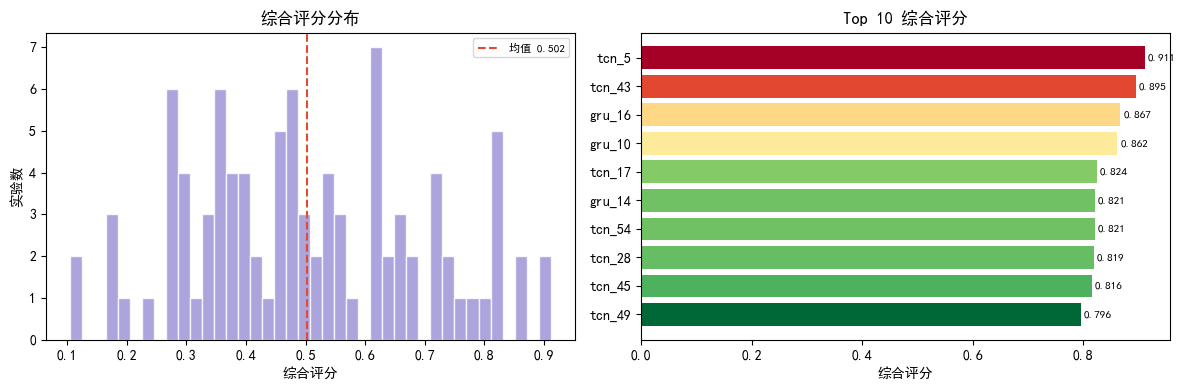

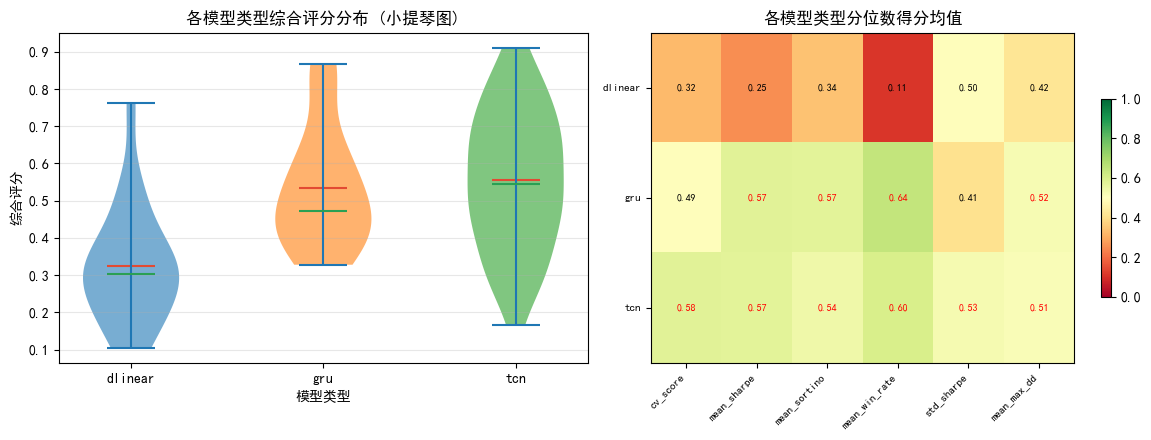

In [5]:
if len(df) > 0:
    # 分位数综合评分
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']

    composite = df[['model_type', 'exp_idx'] + higher_better + lower_better].copy()
    for col in higher_better:
        composite[f'q_{col}'] = composite[col].rank(pct=True)
    for col in lower_better:
        composite[f'q_{col}'] = 1 - composite[col].rank(pct=True)

    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    composite['composite_score'] = composite[q_cols].mean(axis=1)
    composite = composite.sort_values('composite_score', ascending=False).reset_index(drop=True)
    composite['rank'] = range(1, len(composite) + 1)

    display_cols = ['rank', 'model_type', 'exp_idx', 'composite_score'] + [f'q_{c}' for c in higher_better + lower_better] + higher_better + lower_better

    # 分位数着色
    def _highlight_all(val, col_name, table):
        if col_name.startswith('q_'):
            if val >= 0.8:
                return 'background-color: #006837; color: white'
            elif val >= 0.6:
                return 'background-color: #2aa054; color: white'
            elif val >= 0.4:
                return 'background-color: #7fc866'
            else:
                return 'background-color: #f1f9ac'
        return ''
    styled = composite[display_cols].style.map(
        lambda v: _highlight_all(v, 'composite_score', composite), 
        subset=['composite_score']
    )
    for col in q_cols:
        if col in display_cols:
            styled = styled.map(lambda v, c=col: _highlight_all(v, c, composite), subset=[col])

    display(styled)

    # 综合评分分布
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax = axes[0]
    ax.hist(composite['composite_score'], bins=40, color='#988ED5', edgecolor='white', alpha=0.8)
    ax.axvline(composite['composite_score'].mean(), color='#E24A33', linestyle='--', label=f"均值 {composite['composite_score'].mean():.3f}")
    ax.set_xlabel('综合评分')
    ax.set_ylabel('实验数')
    ax.set_title('综合评分分布')
    ax.legend(fontsize=8)

    ax = axes[1]
    top10 = composite.head(10)
    colors = plt.cm.RdYlGn(1 - (top10['composite_score'] - top10['composite_score'].min()) / (top10['composite_score'].max() - top10['composite_score'].min() + 1e-8))
    ax.barh(range(len(top10)), top10['composite_score'], color=colors)
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([f"{r['model_type']}_{r['exp_idx']}" for _, r in top10.iterrows()])
    ax.set_xlabel('综合评分')
    ax.set_title('Top 10 综合评分')
    ax.invert_yaxis()
    for i, v in enumerate(top10['composite_score']):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    # 各模型类别综合评分分布
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]
    mt_labels = sorted(composite['model_type'].unique())
    mt_groups = [composite[composite['model_type'] == mt]['composite_score'] for mt in mt_labels]

    vp = ax.violinplot(mt_groups, positions=range(len(mt_labels)), showmeans=True, showmedians=True)
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(plt.cm.tab10(i % 10))
        body.set_alpha(0.6)
    vp['cmeans'].set_color('#E24A33')
    vp['cmedians'].set_color('#2aa054')
    ax.set_xticks(range(len(mt_labels)))
    ax.set_xticklabels(mt_labels)
    ax.set_xlabel('模型类型')
    ax.set_ylabel('综合评分')
    ax.set_title('各模型类型综合评分分布 (小提琴图)')
    ax.grid(True, alpha=0.3, axis='y')

    ax = axes[1]
    mt_avg = composite.groupby('model_type')[q_cols].mean()
    im = ax.imshow(mt_avg.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(q_cols)))
    ax.set_xticklabels([c.replace('q_', '') for c in q_cols], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(mt_avg)))
    ax.set_yticklabels(mt_avg.index, fontsize=8)
    ax.set_title('各模型类型分位数得分均值')
    for i in range(len(mt_avg)):
        for j in range(len(q_cols)):
            v = mt_avg.values[i, j]
            color = 'red' if v > 0.5 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("暂无完成的 TSCV 结果")

## 3. 模型优选


模型选择结果

DLINEAR:
  Best: exp_17  cv_score=2.3783
  mean_sharpe=2.4121  std_sharpe=0.0338
  mean_max_dd=8.81%  mean_sortino=3.87  mean_win_rate=54.13%
  score=0.76
  超参: lr=4.15e-04  d_model=128  dropout=0.183
        kernel_size=25  num_layers=1
  同类型分布: cv_score 中位数=1.1010  Q1=0.8389  Q3=1.2374  IQR=0.3984
  💡 提示: cv_score=2.3783 > 温和离群上界=1.8350 (Q3+1.5*IQR)，结果较好但需关注可复现性

GRU:
  Best: exp_16  cv_score=2.1752
  mean_sharpe=2.9365  std_sharpe=0.7614
  mean_max_dd=7.03%  mean_sortino=4.77  mean_win_rate=75.88%
  score=0.87
  超参: lr=2.10e-04  d_model=64  dropout=0.175
        num_layers=2
  同类型分布: cv_score 中位数=1.3352  Q1=1.0759  Q3=1.4281  IQR=0.3521
  💡 提示: cv_score=2.1752 > 温和离群上界=1.9562 (Q3+1.5*IQR)，结果较好但需关注可复现性

TCN:
  Best: exp_5  cv_score=2.1865
  mean_sharpe=2.3755  std_sharpe=0.1890
  mean_max_dd=6.90%  mean_sortino=3.98  mean_win_rate=75.90%
  score=0.91
  超参: lr=6.42e-05  d_model=128  dropout=0.179
        kernel_size=3  num_layers=3
  同类型分布: cv_score 中位数=1.4456  Q1=1.1823  Q3=1

,ranking,model_type,exp_idx,cv_score,mean_sharpe,mean_max_dd,mean_sortino,mean_win_rate,score
89,1,tcn,5,2.186520,2.375500,6.898525,3.981225,0.75900,0.911348
27,2,gru,16,2.175156,2.936525,7.032175,4.767350,0.75880,0.867021
8,3,dlinear,17,2.378302,2.412075,8.811650,3.867275,0.54135,0.762411


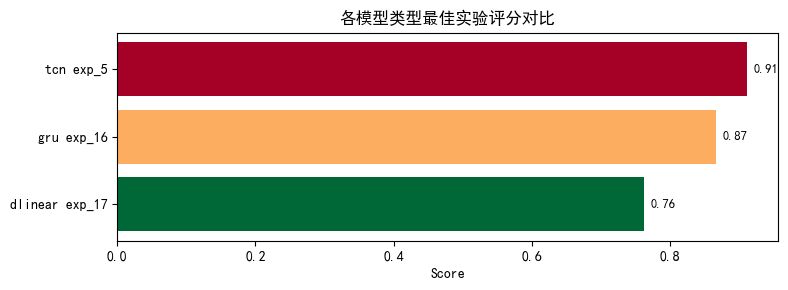

In [6]:
if len(df) > 0 and 'mean_max_dd' in df.columns:
    score_df = df.copy()
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']
    for col in higher_better:
        score_df[f'q_{col}'] = score_df[col].rank(pct=True)
    for col in lower_better:
        score_df[f'q_{col}'] = 1 - score_df[col].rank(pct=True)
    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    score_df['score'] = score_df[q_cols].mean(axis=1)

    print("=" * 70)
    print("模型选择结果")
    print("=" * 70)

    best_per_type = []
    for mt in score_df['model_type'].unique():
        sub = score_df[score_df['model_type'] == mt]
        threshold = sub['cv_score'].quantile(0.85)
        top_group = sub[sub['cv_score'] >= threshold].copy()
        if len(top_group) == 0:
            top_group = sub.nlargest(max(1, len(sub) // 5), 'cv_score')
        top_group = top_group.sort_values('score', ascending=False)
        best = top_group.iloc[0]
        best_per_type.append(best)

        # 离群检验: 检查该实验在同类型中是否严重偏离
        q1, q3 = sub['cv_score'].quantile(0.25), sub['cv_score'].quantile(0.75)
        iqr = q3 - q1
        outlier_upper = q3 + 3.0 * iqr
        outlier_lower = q1 - 3.0 * iqr
        is_outlier = best['cv_score'] > outlier_upper

        print(f"\n{mt.upper()}:")
        print(f"  Best: exp_{int(best['exp_idx'])}  cv_score={best['cv_score']:.4f}")
        print(f"  mean_sharpe={best['mean_sharpe']:.4f}  std_sharpe={best['std_sharpe']:.4f}")
        print(f"  mean_max_dd={best['mean_max_dd']:.2f}%  mean_sortino={best['mean_sortino']:.2f}  mean_win_rate={best['mean_win_rate']:.2%}")
        print(f"  score={best['score']:.2f}")
        print(f"  超参: lr={best['lr']:.2e}  d_model={int(best['d_model'])}  dropout={best['dropout']:.3f}")
        if 'kernel_size' in best and best['kernel_size'] > 0:
            print(f"        kernel_size={int(best['kernel_size'])}  num_layers={int(best['num_layers'])}")
        else:
            print(f"        num_layers={int(best['num_layers'])}")

        # 同类型分布统计
        print(f"  同类型分布: cv_score 中位数={sub['cv_score'].median():.4f}  "
              f"Q1={q1:.4f}  Q3={q3:.4f}  IQR={iqr:.4f}")
        if is_outlier:
            print(f"  ⚠️  警告: cv_score={best['cv_score']:.4f} > 离群上界={outlier_upper:.4f} (Q3+3*IQR)，"
                  f"该实验可能为严重离群值，建议谨慎选用")
        elif best['cv_score'] > q3 + 1.5 * iqr:
            print(f"  💡 提示: cv_score={best['cv_score']:.4f} > 温和离群上界={q3 + 1.5 * iqr:.4f} (Q3+1.5*IQR)，"
                  f"结果较好但需关注可复现性")

    print("\n" + "=" * 70)
    print("全推荐排名表")
    print("=" * 70)
    best_df = pd.DataFrame(best_per_type).sort_values('score', ascending=False)
    best_df['ranking'] = range(1, len(best_df) + 1)
    display(best_df[['ranking', 'model_type', 'exp_idx', 'cv_score',
                     'mean_sharpe', 'mean_max_dd', 'mean_sortino', 'mean_win_rate', 'score']])

    # 最佳模型评分对比
    import matplotlib.pyplot as plt
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(8, max(3, len(best_df) * 0.4)))
    colors = plt.cm.RdYlGn(1 - (best_df['score'] - best_df['score'].min()) /
                           (best_df['score'].max() - best_df['score'].min() + 1e-8))
    ax.barh(range(len(best_df)), best_df['score'], color=colors)
    ax.set_yticks(range(len(best_df)))
    ax.set_yticklabels([f"{r['model_type']} exp_{int(r['exp_idx'])}" for _, r in best_df.iterrows()])
    ax.set_xlabel('Score')
    ax.set_title('各模型类型最佳实验评分对比')
    ax.invert_yaxis()
    for i, v in enumerate(best_df['score']):
        ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("数据不足以进行模型选择（缺少 mean_max_dd）")


## 4. 部署

选择排名第一的模型，生成部署配置。


最佳模型: tcn_exp_5
  目录: ../model/TSCV\bayes_tcn_74_3\exp_5
  cv_score: 2.1865  mean_sharpe: 2.3755  mean_max_dd: 6.90%
  full/ 模型: ❌
  单折模型: 4/4 折可用

方案一: 全量重训 (推荐)
  训练全量模型:
    python code/src/model_manager.py retrain --source TSCV\bayes_tcn_74_3\exp_5
  完成后添加至 config.yaml:
  config.yaml 配置:
    - dir: TSCV\bayes_tcn_74_3\exp_5/full
      file: best_model_sharpe.pth
      enabled: true

方案二: 单折模型
  fold_3 可用 (含 config.json + best_model_sharpe.pth)
  config.yaml 配置:
    - dir: TSCV\bayes_tcn_74_3\exp_5/fold_3
      file: best_model_sharpe.pth
      enabled: true

方案三: 集成 Folds (ensemble_folds)
  使用全部 4 个可用折的模型进行集成推理
  config.yaml 配置:
    - dir: TSCV\bayes_tcn_74_3\exp_5
      type: ensemble_folds
      file: best_model_sharpe.pth
      enabled: true
  ⚠️  需要 config.json 在 TSCV\bayes_tcn_74_3\exp_5 目录中
  ✅ config.json 存在


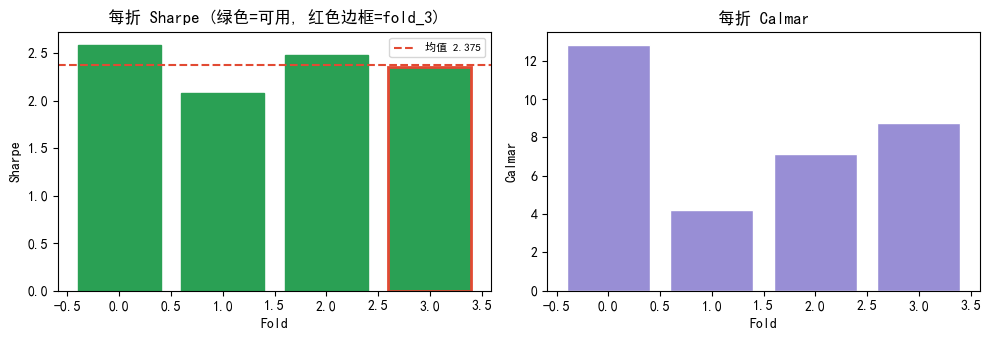


验证命令
  python code/src/daily_eval.py --predictions-only --no-update
  python code/src/daily_eval.py --from-predictions --no-update


In [7]:
if len(df) > 0 and 'mean_max_dd' in df.columns:
    score_df = df.copy()
    higher_better = ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']
    lower_better = ['std_sharpe', 'mean_max_dd']
    for col in higher_better:
        score_df[f'q_{col}'] = score_df[col].rank(pct=True)
    for col in lower_better:
        score_df[f'q_{col}'] = 1 - score_df[col].rank(pct=True)
    q_cols = [f'q_{c}' for c in higher_better + lower_better]
    score_df['score'] = score_df[q_cols].mean(axis=1)

    best_overall = score_df.sort_values('score', ascending=False).iloc[0]
    mt = best_overall['model_type']
    exp_idx = int(best_overall['exp_idx'])

    best_dir = None
    for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split("_")
        mt_short = parts[1] if len(parts) >= 2 else model_type
        if mt_short == mt:
            exp_dir = os.path.join(mt_dir, f"exp_{exp_idx}")
            if os.path.exists(exp_dir):
                best_dir = exp_dir
                break

    if best_dir:
        rel_dir = os.path.relpath(best_dir, start=os.path.join(TSCV_DIR, ".."))
        full_dir = os.path.join(best_dir, "full")
        has_full = os.path.exists(full_dir)
        fold_dirs = sorted(glob.glob(os.path.join(best_dir, "fold_*/")))
        has_folds = len(fold_dirs) > 0
        # Check if fold dirs have config.json and best_model_sharpe.pth
        valid_folds = [d for d in fold_dirs if
                       os.path.exists(os.path.join(d, "best_model_sharpe.pth"))]
        has_valid_folds = len(valid_folds) > 0

        print("=" * 70)
        print(f"最佳模型: {mt}_exp_{exp_idx}")
        print(f"  目录: {best_dir}")
        print(f"  cv_score: {best_overall['cv_score']:.4f}  mean_sharpe: {best_overall['mean_sharpe']:.4f}  mean_max_dd: {best_overall['mean_max_dd']:.2f}%")
        print(f"  full/ 模型: {'✅' if has_full else '❌'}")
        print(f"  单折模型: {f'{len(valid_folds)}/{len(fold_dirs)} 折可用' if has_folds else '无'}")
        print()

        # ----- 方案一: 重训 (full) -----
        print("=" * 70)
        print("方案一: 全量重训 (推荐)")
        print("=" * 70)
        if not has_full:
            print(f"  训练全量模型:")
            print(f"    python code/src/model_manager.py retrain --source {rel_dir}")
            print(f"  完成后添加至 config.yaml:")
        print(f"  config.yaml 配置:")
        print(f"""    - dir: {rel_dir}/full
      file: best_model_sharpe.pth
      enabled: true""")

        # ----- 方案二: 单折 (fold_3) -----
        print()
        print("=" * 70)
        print("方案二: 单折模型")
        print("=" * 70)
        target_fold = "fold_3"
        fold_path = os.path.join(best_dir, target_fold)
        if os.path.exists(fold_path):
            if os.path.exists(os.path.join(fold_path, "best_model_sharpe.pth")):
                print(f"  {target_fold} 可用 (含 config.json + best_model_sharpe.pth)")
                print(f"  config.yaml 配置:")
                print(f"""    - dir: {rel_dir}/{target_fold}
      file: best_model_sharpe.pth
      enabled: true""")
            else:
                print(f"  ⚠️  {target_fold} 目录存在但缺少 config.json 或 best_model_sharpe.pth，不可直接使用")
                if has_valid_folds:
                    print(f"  可选的其他折: {[os.path.basename(d.rstrip('/')) for d in valid_folds]}")
        else:
            print(f"  ⚠️  {target_fold} 不存在")
            if has_valid_folds:
                alt = os.path.basename(valid_folds[0].rstrip("/"))
                print(f"  可选: 使用 {alt} 代替")
                print(f"  config.yaml 配置:")
                print(f"""    - dir: {rel_dir}/{alt}
      file: best_model_sharpe.pth
      enabled: true""")
            else:
                print(f"  ❌ 无可用单折模型")

        # ----- 方案三: 集成fold -----
        print()
        print("=" * 70)
        print("方案三: 集成 Folds (ensemble_folds)")
        print("=" * 70)
        if has_valid_folds:
            print(f"  使用全部 {len(valid_folds)} 个可用折的模型进行集成推理")
            print(f"  config.yaml 配置:")
            print(f"""    - dir: {rel_dir}
      type: ensemble_folds
      file: best_model_sharpe.pth
      enabled: true""")
            print(f"  ⚠️  需要 config.json 在 {rel_dir} 目录中")
            has_parent_cfg = os.path.exists(os.path.join(best_dir, "config.json"))
            print(f"  {'✅' if has_parent_cfg else '❌'} config.json {'存在' if has_parent_cfg else '不存在'}")
        else:
            print(f"  ❌ 无可用 fold 模型，无法集成")

        # 最佳模型每折表现
        result_file = os.path.join(best_dir, "tscv_results.json")
        if os.path.exists(result_file):
            with open(result_file) as f:
                br = json.load(f)
            fold_sharpe = br.get("fold_sharpe", [])
            fold_calmar = br.get("fold_calmar", [])
            if fold_sharpe:
                import matplotlib.pyplot as plt
                plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
                plt.rcParams['axes.unicode_minus'] = False
                fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
                ax = axes[0]

                bars = ax.bar(range(len(fold_sharpe)), fold_sharpe, color='#348ABD', edgecolor='white')
                # highlight valid folds
                for i in range(len(fold_sharpe)):
                    fd = os.path.join(best_dir, f"fold_{i}")
                    if os.path.exists(fd) and os.path.exists(os.path.join(fd, "best_model_sharpe.pth")):
                        bars[i].set_color('#2aa054')
                    # mark fold_3 specifically
                    if i == 3 and os.path.exists(os.path.join(best_dir, "fold_3", "best_model_sharpe.pth")):
                        bars[i].set_edgecolor('#E24A33')
                        bars[i].set_linewidth(2)
                ax.axhline(y=br.get('mean_sharpe', 0), color='#E24A33', linestyle='--', label=f"均值 {br.get('mean_sharpe', 0):.3f}")
                ax.set_xlabel('Fold')
                ax.set_ylabel('Sharpe')
                ax.set_title('每折 Sharpe (绿色=可用, 红色边框=fold_3)')
                ax.legend(fontsize=8)
                if fold_calmar:
                    ax = axes[1]
                    ax.bar(range(len(fold_calmar)), fold_calmar, color='#988ED5', edgecolor='white')
                    ax.set_xlabel('Fold')
                    ax.set_ylabel('Calmar')
                    ax.set_title('每折 Calmar')
                plt.tight_layout()
                plt.show()
        print()
        print("=" * 70)
        print("验证命令")
        print("=" * 70)
        print("  python code/src/daily_eval.py --predictions-only --no-update")
        print("  python code/src/daily_eval.py --from-predictions --no-update")
    else:
        print(f"错误: 未找到 {mt}_exp_{exp_idx} 的目录")
else:
    print("暂无 TSCV 结果可供部署")


## 5. 验证集预测信号分析

基于 `val_predictions.json` 分析最佳模型在每折验证集上的预测信号质量：
- Rank IC 时间序列（预测评分与次日收益的秩相关）
- Top-3 vs Bottom-3 多空组合收益
- 评分稳定性（自相关、每日换手率）
- 各折对比


In [8]:
if 'df' not in dir() or len(df) == 0:
    print('请先运行第1部分加载 TSCV 结果')
else:
    sdf = df.copy()
    for col in ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate']:
        sdf[f'q_{col}'] = sdf[col].rank(pct=True)
    for col in ['std_sharpe', 'mean_max_dd']:
        sdf[f'q_{col}'] = 1 - sdf[col].rank(pct=True)
    q_cols = [f'q_{c}' for c in ['cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate', 'std_sharpe', 'mean_max_dd']]
    sdf['score'] = sdf[q_cols].mean(axis=1)
    best = sdf.sort_values('score', ascending=False).iloc[0]
    best_mt = best['model_type']
    best_exp = int(best['exp_idx'])

    best_dir = None
    for mt_dir in sorted(glob.glob(f'{TSCV_DIR}/*/')):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split('_')
        mt_short = parts[1] if len(parts) >= 2 else model_type
        if mt_short == best_mt:
            exp_dir = os.path.join(mt_dir, f'exp_{best_exp}')
            if os.path.exists(exp_dir):
                best_dir = exp_dir
                break

    if best_dir is None:
        print(f'未找到目录: {best_mt}_exp_{best_exp}')
    else:
        print(f'分析模型: {best_mt}_exp_{best_exp}')
        val_data = {}
        for fi in range(4):
            fp = os.path.join(best_dir, f'fold_{fi}', 'val_predictions.json')
            if os.path.exists(fp):
                with open(fp) as f:
                    val_data[fi] = json.load(f)
                dates_k = sorted(val_data[fi].keys())
                print(f'  fold_{fi}: {len(dates_k)} 天 ({dates_k[0]} ~ {dates_k[-1]})')

        etf = pd.read_csv('../etf_data/etf_74.csv')
        etf.columns = etf.columns.str.replace('\ufeff', '')
        etf['日期'] = pd.to_datetime(etf['日期'])
        print(f'  ETF数据: {etf["股票代码"].nunique()} 只, {etf["日期"].nunique()} 天')


分析模型: tcn_exp_5
  fold_0: 111 天 (2024-07-05 ~ 2024-12-17)
  fold_1: 106 天 (2025-01-03 ~ 2025-06-16)
  fold_2: 112 天 (2025-07-07 ~ 2025-12-17)
  fold_3: 71 天 (2026-01-09 ~ 2026-04-28)
  ETF数据: 74 只, 1070 天


Rank IC (fold_3):
  均值: 0.0208
  标准差: 0.1223
  IR: 0.1698
  IC>0: 54.9%


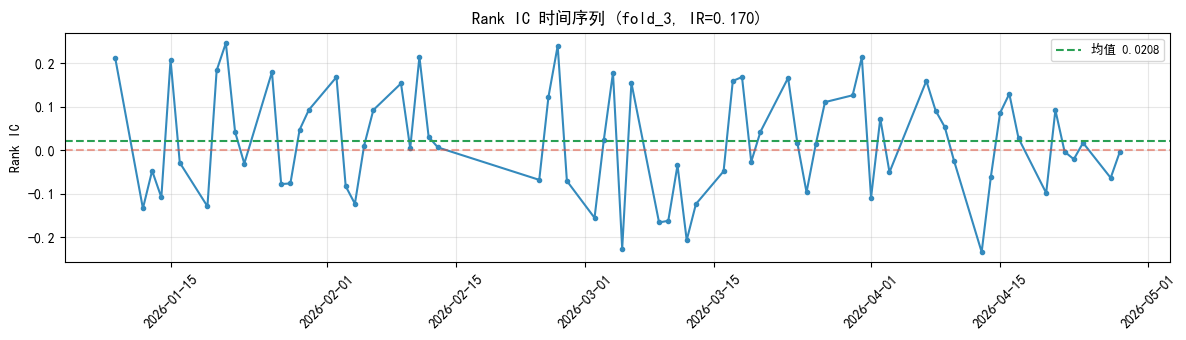

In [9]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

if 'val_data' in dir() and len(val_data) > 0:
    target_fold = 3  # 最接近实盘
    vd = val_data[target_fold]
    ic_rows = []
    for d in sorted(vd.keys()):
        entries = vd[d]
        df_day = pd.DataFrame(entries)
        dt = pd.Timestamp(d)
        next_dates = sorted(etf[etf['日期'] > dt]['日期'].unique())
        if len(next_dates) == 0:
            continue
        next_day = etf[etf['日期'] == next_dates[0]]
        merged = df_day.merge(next_day[['股票代码', '开盘', '收盘']],
                              left_on='stock_id', right_on='股票代码', how='inner')
        if len(merged) < 5:
            continue
        merged['fwd_ret'] = (merged['收盘'] - merged['开盘']) / merged['开盘']
        ic, pv = spearmanr(merged['score'], merged['fwd_ret'])
        ic_rows.append({'date': d, 'ic': ic, 'pval': pv, 'n': len(merged)})

    ic_df = pd.DataFrame(ic_rows)
    ir = ic_df['ic'].mean() / ic_df['ic'].std() if ic_df['ic'].std() > 0 else 0
    print(f'Rank IC (fold_{target_fold}):')
    print(f'  均值: {ic_df["ic"].mean():.4f}')
    print(f'  标准差: {ic_df["ic"].std():.4f}')
    print(f'  IR: {ir:.4f}')
    print(f'  IC>0: {(ic_df["ic"] > 0).mean():.1%}')

    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(pd.to_datetime(ic_df['date']), ic_df['ic'], marker='o', ms=3, color='#348ABD')
    ax.axhline(y=0, color='#E24A33', linestyle='--', alpha=0.5)
    ax.axhline(y=ic_df['ic'].mean(), color='#2aa054', linestyle='--',
               label=f'均值 {ic_df["ic"].mean():.4f}')
    ax.set_title(f'Rank IC 时间序列 (fold_{target_fold}, IR={ir:.3f})')
    ax.set_ylabel('Rank IC')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('无 val_data，请先运行上一单元格')


Top-3 vs Bottom-3 (fold_3):
  Top-3累计收益: 34.12%
  Bottom-3累计收益: 0.59%
  多空累计收益: 33.08%
  日均Spread: 0.4108%
  Spread>0: 64.8%


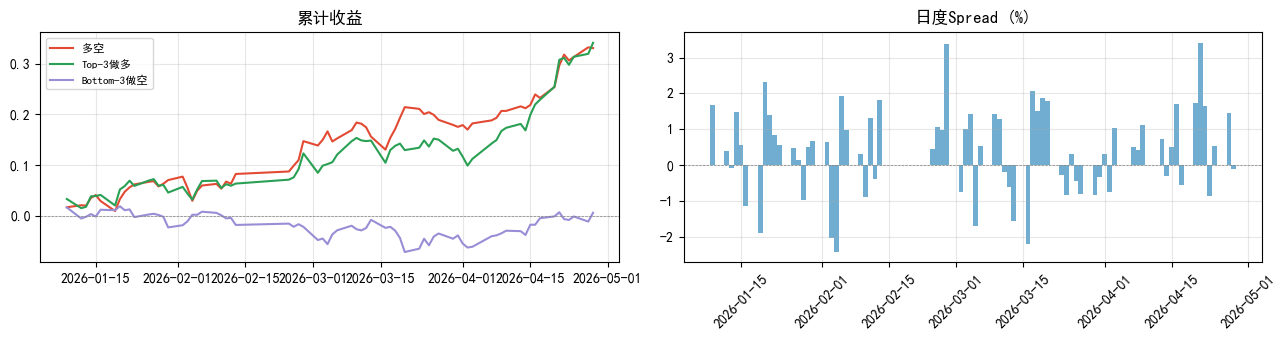

In [10]:
if 'ic_df' in dir() and len(ic_df) > 0:
    target_fold = 3
    vd = val_data[target_fold]
    pnl_rows = []
    for d in sorted(vd.keys()):
        entries = vd[d]
        df_day = pd.DataFrame(entries)
        dt = pd.Timestamp(d)
        next_dates = sorted(etf[etf['日期'] > dt]['日期'].unique())
        if len(next_dates) == 0:
            continue
        next_day = etf[etf['日期'] == next_dates[0]]
        merged = df_day.merge(next_day[['股票代码', '开盘', '收盘']],
                              left_on='stock_id', right_on='股票代码', how='inner')
        if len(merged) < 6:
            continue
        merged['fwd_ret'] = (merged['收盘'] - merged['开盘']) / merged['开盘']
        top3 = merged.nlargest(3, 'score')['fwd_ret'].mean()
        bot3 = merged.nsmallest(3, 'score')['fwd_ret'].mean()
        pnl_rows.append({'date': d, 'top3': top3, 'bottom3': bot3,
                         'spread': top3 - bot3})

    pnl_df = pd.DataFrame(pnl_rows)
    pnl_df['cum_spread'] = (1 + pnl_df['spread']).cumprod() - 1
    pnl_df['cum_top3'] = (1 + pnl_df['top3']).cumprod() - 1
    pnl_df['cum_bottom3'] = (1 + pnl_df['bottom3']).cumprod() - 1

    print(f'Top-3 vs Bottom-3 (fold_{target_fold}):')
    print(f'  Top-3累计收益: {pnl_df["cum_top3"].iloc[-1]*100:.2f}%')
    print(f'  Bottom-3累计收益: {pnl_df["cum_bottom3"].iloc[-1]*100:.2f}%')
    print(f'  多空累计收益: {pnl_df["cum_spread"].iloc[-1]*100:.2f}%')
    print(f'  日均Spread: {pnl_df["spread"].mean()*100:.4f}%')
    print(f'  Spread>0: {(pnl_df["spread"] > 0).mean():.1%}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))
    dates_pd = pd.to_datetime(pnl_df['date'])
    ax1.plot(dates_pd, pnl_df['cum_spread'], color='#E24A33', lw=1.5, label='多空')
    ax1.plot(dates_pd, pnl_df['cum_top3'], color='#2aa054', lw=1.5, label='Top-3做多')
    ax1.plot(dates_pd, pnl_df['cum_bottom3'], color='#988ED5', lw=1.5, label='Bottom-3做空')
    ax1.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax1.set_title('累计收益')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax2.bar(dates_pd, pnl_df['spread'] * 100, width=1, color='#348ABD', alpha=0.7)
    ax2.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax2.set_title('日度Spread (%)')
    ax2.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('无数据，请先运行前序单元格')


评分自相关 (fold_3):
  均值: 0.9864
  中位数: 0.9907
  P90: 0.9944
  P10: 0.9756

Top-3日度换手率:
  均值: 4.3%
  中位数: 0.0%
  全不变比例: 87.1%
  全换比例: 0.0%


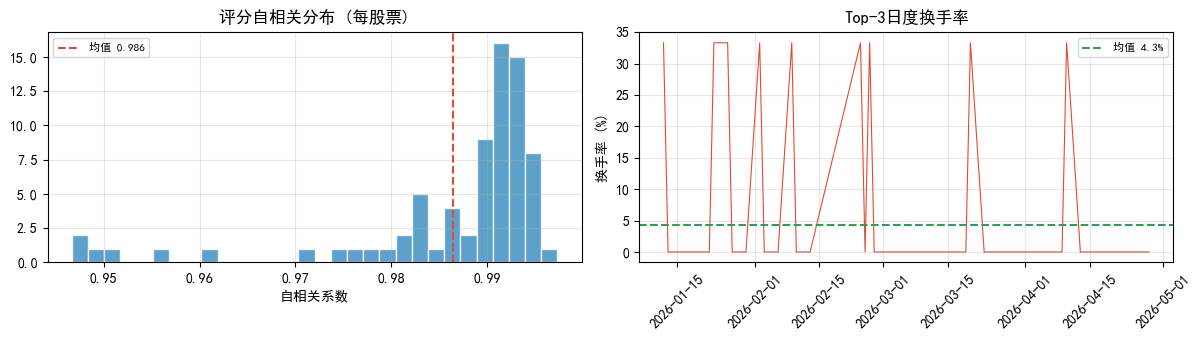

In [11]:
if 'val_data' in dir() and len(val_data) > 0:
    target_fold = 3
    vd = val_data[target_fold]
    dates = sorted(vd.keys())

    # Score autocorrelation: 每个股票在全时段上的分数自相关
    all_scores = {}  # stock_id -> [scores in date order]
    for d in dates:
        for entry in vd[d]:
            sid = entry['stock_id']
            sc = entry['score']
            if sid not in all_scores:
                all_scores[sid] = []
            all_scores[sid].append(sc)

    autocorrs = []
    for sid, scores in all_scores.items():
        if len(scores) >= 20:
            arr = pd.Series(scores)
            ac = arr.autocorr()
            if not np.isnan(ac):
                autocorrs.append(ac)

    autocorrs = np.array(autocorrs)
    print(f'评分自相关 (fold_{target_fold}):')
    print(f'  均值: {autocorrs.mean():.4f}')
    print(f'  中位数: {np.median(autocorrs):.4f}')
    print(f'  P90: {np.percentile(autocorrs, 90):.4f}')
    print(f'  P10: {np.percentile(autocorrs, 10):.4f}')

    # Top-3 day-over-day turnover
    prev_top3 = None
    turnovers = []
    for d in dates:
        entries = sorted(vd[d], key=lambda x: x['score'], reverse=True)
        top3 = {e['stock_id'] for e in entries[:3]}
        if prev_top3 is not None:
            overlap = len(top3 & prev_top3)
            turnovers.append(1 - overlap / 3)
        prev_top3 = top3

    turnovers = np.array(turnovers)
    print(f'\nTop-3日度换手率:')
    print(f'  均值: {turnovers.mean()*100:.1f}%')
    print(f'  中位数: {np.median(turnovers)*100:.1f}%')
    print(f'  全不变比例: {(turnovers == 0).mean()*100:.1f}%')
    print(f'  全换比例: {(turnovers == 1).mean()*100:.1f}%')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
    ax1.hist(autocorrs, bins=30, color='#348ABD', edgecolor='white', alpha=0.8)
    ax1.axvline(x=autocorrs.mean(), color='#E24A33', ls='--',
                label=f'均值 {autocorrs.mean():.3f}')
    ax1.set_title('评分自相关分布 (每股票)')
    ax1.set_xlabel('自相关系数')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax2.plot(pd.to_datetime(dates[1:]), turnovers * 100, color='#E24A33', lw=0.8)
    ax2.axhline(y=turnovers.mean()*100, color='#2aa054', ls='--',
                label=f'均值 {turnovers.mean()*100:.1f}%')
    ax2.set_title('Top-3日度换手率')
    ax2.set_ylabel('换手率 (%)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('无数据')


In [12]:
if 'val_data' in dir() and len(val_data) > 0:
    from scipy.stats import spearmanr
    fold_results = []
    for fi in sorted(val_data.keys()):
        vd = val_data[fi]
        ic_list = []
        spread_list = []
        for d in sorted(vd.keys()):
            entries = vd[d]
            df_day = pd.DataFrame(entries)
            dt = pd.Timestamp(d)
            next_dates = sorted(etf[etf['日期'] > dt]['日期'].unique())
            if len(next_dates) == 0:
                continue
            next_day = etf[etf['日期'] == next_dates[0]]
            merged = df_day.merge(next_day[['股票代码', '开盘', '收盘']],
                                  left_on='stock_id', right_on='股票代码', how='inner')
            if len(merged) < 6:
                continue
            merged['fwd_ret'] = (merged['收盘'] - merged['开盘']) / merged['开盘']
            ic, _ = spearmanr(merged['score'], merged['fwd_ret'])
            ic_list.append(ic)
            top3 = merged.nlargest(3, 'score')['fwd_ret'].mean()
            bot3 = merged.nsmallest(3, 'score')['fwd_ret'].mean()
            spread_list.append(top3 - bot3)

        ic_arr = np.array(ic_list)
        spread_arr = np.array(spread_list)
        dates_k = sorted(vd.keys())
        fold_results.append({
            'fold': f'fold_{fi}',
            '天数': len(ic_arr),
            '日期范围': f'{dates_k[0]}~{dates_k[-1]}',
            'IC均值': f'{ic_arr.mean():.4f}',
            'IC标准差': f'{ic_arr.std():.4f}',
            'IR': f'{ic_arr.mean() / ic_arr.std():.2f}' if ic_arr.std() > 0 else 'N/A',
            'IC>0%': f'{(ic_arr > 0).mean()*100:.0f}%',
            'Spread均值%': f'{spread_arr.mean()*100:.3f}%',
            'Spread>0%': f'{(spread_arr > 0).mean()*100:.0f}%',
        })

    fold_cmp = pd.DataFrame(fold_results)
    display(fold_cmp)
else:
    print('无数据')


,fold,天数,日期范围,IC均值,IC标准差,IR,IC>0%,Spread均值%,Spread>0%
0,fold_0,111,2024-07-05~2024-12-17,0.0060,0.1570,0.04,52%,-0.028%,45%
1,fold_1,106,2025-01-03~2025-06-16,-0.0158,0.1194,-0.13,45%,-0.235%,42%
2,fold_2,112,2025-07-07~2025-12-17,-0.0330,0.1881,-0.18,43%,-0.256%,40%
3,fold_3,71,2026-01-09~2026-04-28,0.0208,0.1214,0.17,55%,0.411%,65%


### 小结

以上分析显示：
- **Rank IC**: 各折验证集上预测评分与次日收益之间的秩相关程度
- **多空组合**: Top-3 vs Bottom-3 的 Spread 累计收益
- **评分稳定性**: 模型评分在时间序列上的自相关性（较高的自相关意味着选股逻辑稳定，但过高的自相关可能意味着评分变化不足）
- **换手率**: Top-3 的日度换手率反映了模型对持仓的调整频率

通常期望：IC 均值 > 0、Spread 累计收益向上、IC>0 比例 > 50%。若 fold_3 的信号质量显著劣于前 3 折，说明模型存在过拟合。


## 6. 多模型预测信号批量对比

对全部实验的 fold_3 验证集计算 Rank IC 和 Top-3/Bottom-3 Spread，比较不同模型的预测信号质量。


In [13]:
if 'df' not in dir() or len(df) == 0 or 'etf' not in dir():
    print('请先运行第1部分加载 TSCV 结果')
else:
    import time
    from scipy.stats import spearmanr
    t0 = time.time()
    print("批量计算各实验 fold_3 信号指标...")

    etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
    etf_sorted['_next_close'] = etf_sorted.groupby('股票代码')['收盘'].shift(-1)
    etf_sorted['_next_open'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
    etf_sorted['fwd_ret'] = (etf_sorted['_next_close'] - etf_sorted['_next_open']) / etf_sorted['_next_open']
    fwd_lookup = etf_sorted[['股票代码', '日期', 'fwd_ret']].dropna()

    all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    idx_to_date = {i: d for d, i in date_to_idx.items()}

    metrics_rows = []
    total = 0
    for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split("_")
        mt_short = parts[1] if len(parts) >= 2 else model_type
        for exp_dir in sorted(glob.glob(f"{mt_dir}exp_*/")):
            exp_idx = int(os.path.basename(os.path.normpath(exp_dir)).split("_")[1])
            vp_file = os.path.join(exp_dir, "fold_3", "val_predictions.json")
            if not os.path.exists(vp_file):
                continue
            with open(vp_file) as f:
                vp = json.load(f)

            rows = []
            for d, entries in vp.items():
                dt = pd.to_datetime(d)
                for e in entries:
                    rows.append({'date': dt, 'stock_id': e['stock_id'], 'score': e['score']})
            fold_df = pd.DataFrame(rows)
            fold_df['_date_idx'] = fold_df['date'].map(date_to_idx)
            fold_df['_next_idx'] = fold_df['_date_idx'] + 1
            fold_df['_next_date'] = fold_df['_next_idx'].map(idx_to_date)
            fold_df = fold_df.dropna(subset=['_next_date'])

            merged = fold_df.merge(fwd_lookup, left_on=['stock_id', '_next_date'],
                                   right_on=['股票代码', '日期'], how='inner')
            if len(merged) == 0:
                continue

            ic_vals = merged.groupby('date').apply(
                lambda g: spearmanr(g['score'], g['fwd_ret'])[0], include_groups=False)
            spread_vals = merged.groupby('date').apply(
                lambda g: (g.nlargest(3, 'score')['fwd_ret'].mean() -
                           g.nsmallest(3, 'score')['fwd_ret'].mean()), include_groups=False)

            metrics_rows.append({
                'model_type': mt_short, 'exp_idx': exp_idx,
                'ic_mean': ic_vals.mean(), 'ic_std': ic_vals.std(),
                'ir': ic_vals.mean() / ic_vals.std() if ic_vals.std() > 0 else 0,
                'ic_pos': (ic_vals > 0).mean(),
                'spread_mean': spread_vals.mean(),
                'spread_pos': (spread_vals > 0).mean(),
                'n_days': len(ic_vals),
            })
            total += 1
            if total % 20 == 0:
                print(f"  ... {total} exp ({time.time()-t0:.0f}s)")

    metrics_df = pd.DataFrame(metrics_rows)
    print(f"完成: {len(metrics_df)} exp, {time.time()-t0:.0f}s")



批量计算各实验 fold_3 信号指标...
  ... 20 exp (9s)
  ... 40 exp (15s)
  ... 60 exp (24s)
  ... 80 exp (32s)
完成: 94 exp, 38s


In [14]:
if 'metrics_df' in dir() and len(metrics_df) > 0:
    top20 = metrics_df.nlargest(20, 'ic_mean').reset_index(drop=True)
    top20.index = range(1, len(top20) + 1)
    display_cols = ['model_type', 'exp_idx', 'ic_mean', 'ic_std', 'ir', 'ic_pos', 'spread_mean', 'spread_pos', 'n_days']
    display_df = top20[display_cols].copy()
    display_df['ic_pos'] = display_df['ic_pos'].map('{:.0%}'.format)
    display_df['spread_pos'] = display_df['spread_pos'].map('{:.0%}'.format)
    display_df['ic_mean'] = display_df['ic_mean'].map('{:.4f}'.format)
    display_df['ic_std'] = display_df['ic_std'].map('{:.4f}'.format)
    display_df['ir'] = display_df['ir'].map('{:.2f}'.format)
    display_df['spread_mean'] = display_df['spread_mean'].map('{:.4f}'.format)
    print(f'Top-20 实验, 按 fold_3 IC均值排序:')
    display(display_df)

    grp = metrics_df.groupby('model_type')['ic_mean'].agg(['count', 'mean', 'std', 'max'])
    grp.columns = ['实验数', 'IC均值', 'IC标准差', 'IC最大']
    print(f'\n按模型类型汇总:')
    display(grp)
else:
    print('请先运行批量计算单元格')

Top-20 实验, 按 fold_3 IC均值排序:


,model_type,exp_idx,ic_mean,ic_std,ir,ic_pos,spread_mean,spread_pos,n_days
1,gru,9,0.0556,0.2155,0.26,65%,0.0033,65%,71
2,dlinear,17,0.0534,0.1604,0.33,69%,0.0005,55%,71
3,dlinear,10,0.0524,0.2045,0.26,62%,0.0013,49%,71
4,dlinear,0,0.0520,0.1959,0.27,59%,0.0023,55%,71
5,gru,8,0.0478,0.1853,0.26,63%,0.0014,46%,71
6,dlinear,2,0.0448,0.1781,0.25,62%,0.0009,51%,71
7,dlinear,19,0.0433,0.1881,0.23,55%,0.0001,52%,71
8,tcn,39,0.0426,0.1573,0.27,66%,0.0009,55%,71
9,tcn,29,0.0424,0.1562,0.27,66%,0.0021,58%,71
10,gru,3,0.0389,0.1671,0.23,61%,-0.0000,48%,71



按模型类型汇总:


,实验数,IC均值,IC标准差,IC最大
model_type,,,,
dlinear,20,0.020274,0.021196,0.053350
gru,20,0.029579,0.011425,0.055613
tcn,54,0.021843,0.010166,0.042550


cv_score vs IC_mean: 0.1911
fold_3_Sharpe vs IC_mean: 0.2125


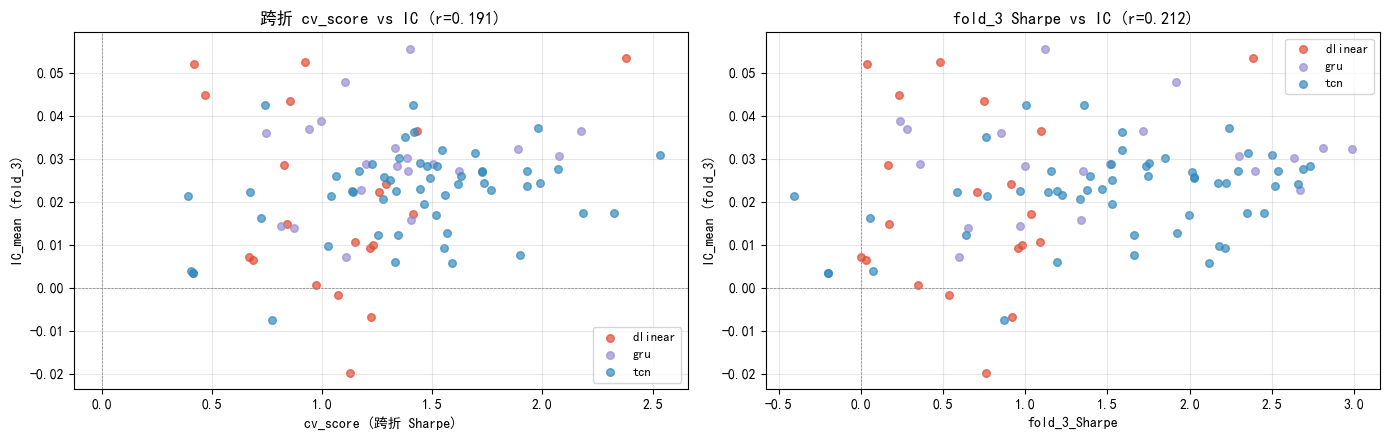

In [15]:
if 'metrics_df' in dir() and len(metrics_df) > 0 and 'df' in dir() and len(df) > 0:
    merged = metrics_df.merge(
        df[['model_type', 'exp_idx', 'cv_score', 'mean_sharpe', 'fold_3_sharpe']],
        on=['model_type', 'exp_idx'], how='left')
    merged = merged.dropna(subset=['cv_score'])

    corr_cv = merged['cv_score'].corr(merged['ic_mean'])
    corr_f3 = merged['fold_3_sharpe'].corr(merged['ic_mean'])
    print(f'cv_score vs IC_mean: {corr_cv:.4f}')
    print(f'fold_3_Sharpe vs IC_mean: {corr_f3:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    colors = {'tcn': '#348ABD', 'dlinear': '#E24A33', 'gru': '#988ED5'}
    for mt in merged['model_type'].unique():
        sub = merged[merged['model_type'] == mt]
        ax1.scatter(sub['cv_score'], sub['ic_mean'],
                    c=colors.get(mt, '#888888'), label=mt, alpha=0.7, s=30)
        ax2.scatter(sub['fold_3_sharpe'], sub['ic_mean'],
                    c=colors.get(mt, '#888888'), label=mt, alpha=0.7, s=30)
    for ax in [ax1, ax2]:
        ax.axhline(y=0, color='gray', ls='--', lw=0.5)
        ax.axvline(x=0, color='gray', ls='--', lw=0.5)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    ax1.set_xlabel('cv_score (跨折 Sharpe)')
    ax1.set_ylabel('IC_mean (fold_3)')
    ax1.set_title(f'跨折 cv_score vs IC (r={corr_cv:.3f})')
    ax2.set_xlabel('fold_3_Sharpe')
    ax2.set_ylabel('IC_mean (fold_3)')
    ax2.set_title(f'fold_3 Sharpe vs IC (r={corr_f3:.3f})')
    plt.tight_layout()
    plt.show()
else:
    print('需要 metrics_df + df，请先运行前序单元格')


## 7. IC 衰减分析

计算 Top-20 实验在 1d/5d/10d/20d 持有期上的 IC，观察信号有效时长。
衰减越慢的模型，信号越持久，越适合实际交易。


In [16]:
if 'metrics_df' not in dir() or len(metrics_df) == 0 or 'etf' not in dir():
    print('请先运行第6节批量计算')
else:
    from scipy.stats import spearmanr
    top20 = metrics_df.nlargest(20, 'ic_mean').reset_index(drop=True)

    etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
    etf_sorted['_open_d1'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
    fwd_multi = etf_sorted[['股票代码', '日期']].copy()
    fwd_cols = []
    for h in [1, 5, 10, 20]:
        col = f'close_d{h}'
        fwd_multi[col] = etf_sorted.groupby('股票代码')['收盘'].shift(-h)
        ret_col = f'fwd_ret_{h}d'
        fwd_multi[ret_col] = (fwd_multi[col] - etf_sorted['_open_d1']) / etf_sorted['_open_d1']
        fwd_cols.append(ret_col)
    fwd_multi = fwd_multi[['股票代码', '日期'] + fwd_cols].dropna()

    all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    idx_to_date = {i: d for d, i in date_to_idx.items()}

    decay_rows = []
    for _, row in top20.iterrows():
        mt = row['model_type']
        ei = int(row['exp_idx'])
        vp_file = None
        for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
            model_type = os.path.basename(os.path.normpath(mt_dir))
            parts = model_type.split("_")
            mt_short = parts[1] if len(parts) >= 2 else model_type
            if mt_short == mt:
                tp = os.path.join(mt_dir, f"exp_{ei}", "fold_3", "val_predictions.json")
                if os.path.exists(tp):
                    vp_file = tp
                    break
        if vp_file is None:
            continue
        with open(vp_file) as f:
            vp = json.load(f)

        rows = []
        for d, entries in vp.items():
            dt = pd.to_datetime(d)
            for e in entries:
                rows.append({'日期': dt, '股票代码': e['stock_id'], 'score': e['score']})
        fold_df = pd.DataFrame(rows)

        merged = fold_df.merge(fwd_multi, on=['股票代码', '日期'], how='inner')
        if len(merged) < 5:
            continue

        ic_row = {'model_type': mt, 'exp_idx': ei}
        for h, rc in zip([1, 5, 10, 20], fwd_cols):
            ic_vals = merged.groupby('日期').apply(
                lambda g: spearmanr(g['score'], g[rc])[0], include_groups=False)
            ic_row[f'ic_{h}d'] = ic_vals.mean()
        decay_rows.append(ic_row)

    decay_df = pd.DataFrame(decay_rows)
    print(f'IC衰减计算完成: {len(decay_df)} 个实验')
    display(decay_df.round(4))



IC衰减计算完成: 20 个实验


,model_type,exp_idx,ic_1d,ic_5d,ic_10d,ic_20d
0,gru,9,0.0572,0.0958,0.1453,0.2059
1,dlinear,17,0.0461,0.1331,0.1654,0.2216
2,dlinear,10,0.0146,0.0656,0.0677,0.0934
3,dlinear,0,0.0252,0.0453,0.0488,0.0925
4,gru,8,0.0473,0.0806,0.1157,0.1624
5,dlinear,2,-0.0132,0.0704,0.1028,0.1301
6,dlinear,19,-0.0183,0.0478,0.0777,0.1118
7,tcn,39,0.0436,0.0708,0.1081,0.1373
8,tcn,29,0.0430,0.0633,0.0914,0.1086
9,gru,3,0.0399,0.0562,0.0838,0.1128


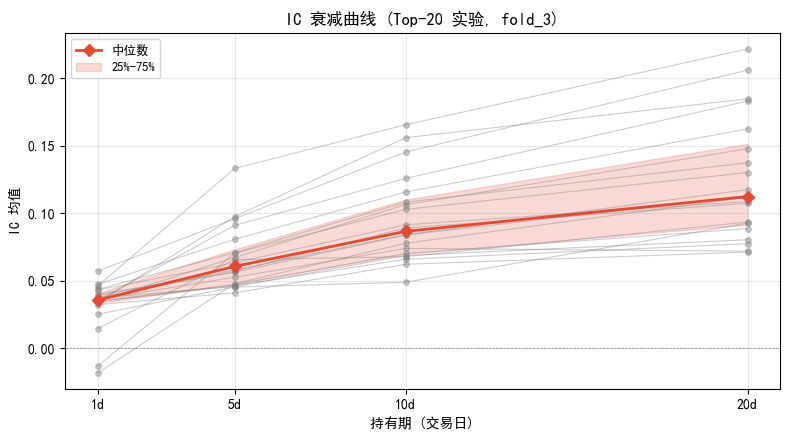

各持有期中位数 IC:
  1d: 0.0356
  5d: 0.0606
  10d: 0.0865
  20d: 0.1123


In [17]:
if 'decay_df' in dir() and len(decay_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    horizons = [1, 5, 10, 20]
    labels = ['1d', '5d', '10d', '20d']

    ic_data = decay_df[[f'ic_{h}d' for h in horizons]].values
    median_ic = np.median(ic_data, axis=0)
    p25 = np.percentile(ic_data, 25, axis=0)
    p75 = np.percentile(ic_data, 75, axis=0)

    for i in range(len(decay_df)):
        vals = ic_data[i]
        label = decay_df.iloc[i]['model_type'] + '_' + str(decay_df.iloc[i]['exp_idx'])
        ax.plot(horizons, vals, marker='o', ms=4, lw=0.8, alpha=0.4, color='gray')

    ax.plot(horizons, median_ic, marker='D', ms=6, lw=2, color='#E24A33', label='中位数')
    ax.fill_between(horizons, p25, p75, alpha=0.2, color='#E24A33', label='25%-75%')
    ax.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('持有期 (交易日)')
    ax.set_ylabel('IC 均值')
    ax.set_title('IC 衰减曲线 (Top-20 实验, fold_3)')
    ax.set_xticks(horizons)
    ax.set_xticklabels(labels)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('各持有期中位数 IC:')
    for h, l in zip(horizons, labels):
        print(f'  {l}: {np.median(ic_data[:, horizons.index(h)]):.4f}')
else:
    print('请先计算 IC 衰减')

## 8. 分位数单调性检验

按 score 将 ETF 分为 10 组（decile），计算每组等权次日收益。
若评分有效，decile_1（评分最高）收益 > decile_2 > ... > decile_10（评分最低）。


In [18]:
if 'metrics_df' not in dir() or len(metrics_df) == 0 or 'etf' not in dir():
    print('请先运行第6节批量计算')
else:
    from scipy.stats import spearmanr
    top3 = metrics_df.nlargest(3, 'ic_mean').reset_index(drop=True)

    etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
    etf_sorted['_next_close'] = etf_sorted.groupby('股票代码')['收盘'].shift(-1)
    etf_sorted['_next_open'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
    etf_sorted['fwd_ret'] = (etf_sorted['_next_close'] - etf_sorted['_next_open']) / etf_sorted['_next_open']
    fwd_lookup = etf_sorted[['股票代码', '日期', 'fwd_ret']].dropna()

    all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    idx_to_date = {i: d for d, i in date_to_idx.items()}

    decile_rows = []
    for _, row in top3.iterrows():
        mt = row['model_type']
        ei = int(row['exp_idx'])
        vp_file = None
        for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
            model_type = os.path.basename(os.path.normpath(mt_dir))
            parts = model_type.split("_")
            mt_short = parts[1] if len(parts) >= 2 else model_type
            if mt_short == mt:
                tp = os.path.join(mt_dir, f"exp_{ei}", "fold_3", "val_predictions.json")
                if os.path.exists(tp):
                    vp_file = tp
                    break
        if vp_file is None:
            continue
        with open(vp_file) as f:
            vp = json.load(f)

        all_merged = []
        for d, entries in vp.items():
            dt = pd.to_datetime(d)
            df_day = pd.DataFrame(entries)
            df_day['日期'] = dt
            df_day = df_day.rename(columns={'stock_id': '股票代码'})
            idx = date_to_idx.get(dt)
            if idx is None:
                continue
            next_dt = idx_to_date.get(idx + 1)
            if next_dt is None:
                continue
            ret_row = fwd_lookup[(fwd_lookup['股票代码'].isin(df_day['股票代码'])) &
                                 (fwd_lookup['日期'] == next_dt)]
            if len(ret_row) == 0:
                continue
            merged = df_day.merge(ret_row[['股票代码', 'fwd_ret']], on='股票代码', how='inner')
            if len(merged) < 10:
                continue
            merged['decile'] = pd.qcut(merged['score'], 10, labels=False, duplicates='drop')
            all_merged.append(merged)

        if len(all_merged) == 0:
            continue
        all_merged = pd.concat(all_merged, ignore_index=True)
        decile_ret = all_merged.groupby('decile')['fwd_ret'].mean()
        decile_rows.append({'model_type': mt, 'exp_idx': ei, **{f'd{i+1}': decile_ret.get(i, 0) for i in range(10)}})

    if len(decile_rows) == 0:
        print('无数据')
    else:
        decile_df = pd.DataFrame(decile_rows)
        print('各组等权次日收益均值:')
        display(decile_df.round(6))



各组等权次日收益均值:


,model_type,exp_idx,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10
0,gru,9,-0.000514,0.000002,-0.000145,0.000301,0.000057,0.001893,0.001380,0.001590,0.000397,0.000970
1,dlinear,17,0.000075,-0.001323,0.001477,-0.000209,0.000902,-0.000552,0.001348,0.001423,0.001429,0.001297
2,dlinear,10,-0.000166,0.000752,-0.000254,0.000940,0.000444,0.000411,0.000135,0.001412,0.000545,0.001643


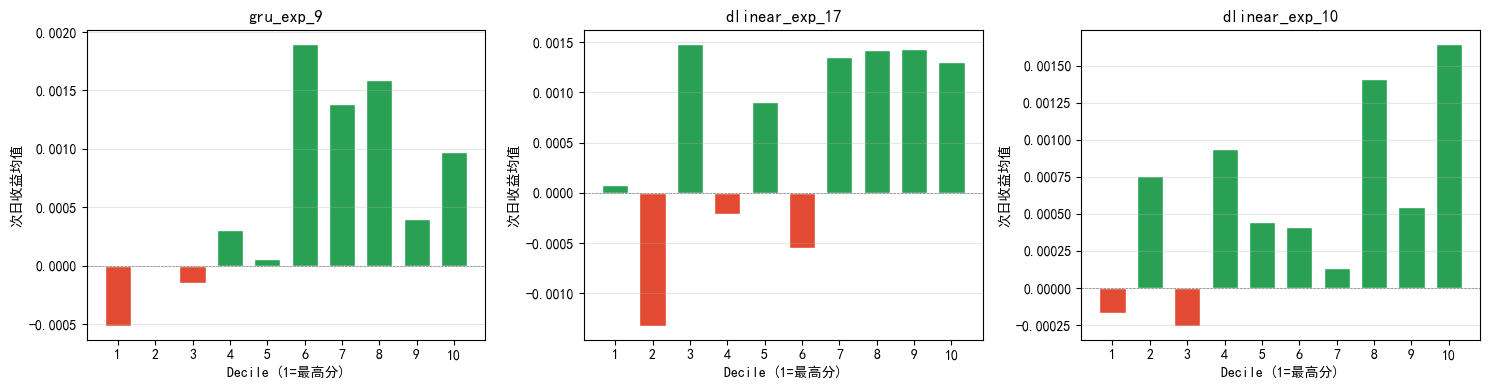

In [19]:
if 'decile_df' in dir() and len(decile_df) > 0:
    fig, axes = plt.subplots(1, len(decile_df), figsize=(5 * len(decile_df), 4))
    if len(decile_df) == 1:
        axes = [axes]
    for idx, (_, row) in enumerate(decile_df.iterrows()):
        ax = axes[idx]
        vals = [row[f'd{i+1}'] for i in range(10)]
        colors_bar = ['#2aa054' if v > 0 else '#E24A33' for v in vals]
        bars = ax.bar(range(1, 11), vals, color=colors_bar, edgecolor='white', width=0.7)
        ax.axhline(y=0, color='gray', ls='--', lw=0.5)
        ax.set_xlabel('Decile (1=最高分)')
        ax.set_ylabel('次日收益均值')
        ax.set_title(f'{row["model_type"]}_exp_{int(row["exp_idx"])}')
        ax.set_xticks(range(1, 11))
        ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('请先计算分位数收益')

## 9. 条件 IC

按市场状态分层计算 IC，检验模型在不同环境下的稳定性。


In [20]:
if 'metrics_df' not in dir() or len(metrics_df) == 0 or 'etf' not in dir():
    print('请先运行第6节批量计算')
else:
    from scipy.stats import spearmanr
    best_exp = metrics_df.nlargest(1, 'ic_mean').iloc[0]
    mt, ei = best_exp['model_type'], int(best_exp['exp_idx'])
    print(f'分析模型: {mt}_exp_{ei}')

    vp_file = None
    for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split("_")
        mt_short = parts[1] if len(parts) >= 2 else model_type
        if mt_short == mt:
            tp = os.path.join(mt_dir, f"exp_{ei}", "fold_3", "val_predictions.json")
            if os.path.exists(tp):
                vp_file = tp
                break
    if vp_file is None:
        print('未找到 val_predictions')
    else:
        with open(vp_file) as f:
            vp = json.load(f)

        etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
        etf_sorted['_next_close'] = etf_sorted.groupby('股票代码')['收盘'].shift(-1)
        etf_sorted['_next_open'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
        etf_sorted['fwd_ret'] = (etf_sorted['_next_close'] - etf_sorted['_next_open']) / etf_sorted['_next_open']
        fwd_lookup = etf_sorted[['股票代码', '日期', 'fwd_ret']].dropna()

        all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
        date_to_idx = {d: i for i, d in enumerate(all_dates)}
        idx_to_date = {i: d for d, i in date_to_idx.items()}

        daily_ic = []
        daily_mkt_ret = []
        for d, entries in vp.items():
            dt = pd.to_datetime(d)
            df_day = pd.DataFrame(entries)
            df_day = df_day.rename(columns={'stock_id': '股票代码'})
            df_day['日期'] = dt
            idx = date_to_idx.get(dt)
            if idx is None: continue
            next_dt = idx_to_date.get(idx + 1)
            if next_dt is None: continue
            merged = df_day.merge(
                fwd_lookup[(fwd_lookup['日期'] == next_dt)],
                on=['股票代码', '日期'], how='inner')
            if len(merged) < 5: continue
            ic, _ = spearmanr(merged['score'], merged['fwd_ret'])
            daily_ic.append({'date': dt, 'ic': ic})
            daily_mkt_ret.append({'date': dt, 'mkt_ret': merged['fwd_ret'].mean()})

        if len(daily_ic) == 0:
            print('无有效日期 (所有合并结果不足5只)')
            cond_results = pd.DataFrame()
        else:
            ic_by_date = pd.DataFrame(daily_ic)
            mkt = pd.DataFrame(daily_mkt_ret)
            df_cond = ic_by_date.merge(mkt, on='date')
            df_cond['vol'] = df_cond['mkt_ret'].abs()
            med_vol = df_cond['vol'].median()

            cond_up = df_cond[df_cond['mkt_ret'] > 0]['ic']
            cond_down = df_cond[df_cond['mkt_ret'] <= 0]['ic']
            cond_high_vol = df_cond[df_cond['vol'] >= med_vol]['ic']
            cond_low_vol = df_cond[df_cond['vol'] < med_vol]['ic']

            cond_results = pd.DataFrame({
            '条件': ['上涨日', '下跌日', '高波动日', '低波动日'],
            '天数': [len(cond_up), len(cond_down), len(cond_high_vol), len(cond_low_vol)],
            'IC均值': [cond_up.mean(), cond_down.mean(), cond_high_vol.mean(), cond_low_vol.mean()],
            'IC>0%': [(cond_up > 0).mean(), (cond_down > 0).mean(), (cond_high_vol > 0).mean(), (cond_low_vol > 0).mean()],
            })
            display(cond_results)



分析模型: gru_exp_9
无有效日期 (所有合并结果不足5只)


In [21]:
if 'cond_results' in dir() and len(cond_results) > 0:
    fig, ax = plt.subplots(figsize=(7, 4))
    x = range(len(cond_results))
    bars = ax.bar(x, cond_results['IC均值'], width=0.5, color=['#2aa054', '#E24A33', '#348ABD', '#988ED5'], edgecolor='white')
    for i, (_, row) in enumerate(cond_results.iterrows()):
        ax.text(i, row['IC均值'] + 0.002 if row['IC均值'] >= 0 else row['IC均值'] - 0.012,
                f"n={row['天数']}\n{row['IC>0%']:.0%}", ha='center', fontsize=9)
    ax.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(cond_results['条件'])
    ax.set_ylabel('IC 均值')
    ax.set_title('条件 IC (最佳模型, fold_3)')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('请先计算条件IC')

请先计算条件IC


## 10. 模型预测相关性

用 `predictions.json` 中多个模型的评分计算 Spearman 相关系数，评估模型多样性。


In [22]:
PRED_FILE = '../output/predictions.json'
if not os.path.exists(PRED_FILE):
    print(f'未找到 {PRED_FILE}，请先生成预测')
else:
    from scipy.stats import spearmanr
    with open(PRED_FILE) as f:
        preds = json.load(f)

    model_keys = [k for k in preds if k != '_meta']
    print(f'可用模型: {model_keys}')

    all_scores = {}
    for mk in model_keys:
        for d, entries in preds[mk].items():
            for e in entries:
                key = (d, e['stock_id'])
                if key not in all_scores:
                    all_scores[key] = {}
                all_scores[key][mk] = e['score']

    score_df = pd.DataFrame.from_dict(all_scores, orient='index').dropna()
    print(f'共 {len(score_df)} 条 (日期×股票) 记录')

    corr_matrix = score_df.corr(method='spearman')
    print('\nSpearman 相关系数矩阵:')
    display(corr_matrix.round(4))

可用模型: ['tcn_5_3', 'tcn_5_2', 'tcn_5_1', 'tcn_5_0', 'average', 'voting']
共 138 条 (日期×股票) 记录

Spearman 相关系数矩阵:


,tcn_5_3,tcn_5_2,tcn_5_1,tcn_5_0,average,voting
tcn_5_3,1.0000,-0.4645,-0.7272,0.5321,-0.1362,0.0177
tcn_5_2,-0.4645,1.0000,0.4716,-0.2338,0.7889,0.7464
tcn_5_1,-0.7272,0.4716,1.0000,-0.0144,0.0901,0.0861
tcn_5_0,0.5321,-0.2338,-0.0144,1.0000,-0.2420,-0.1207
average,-0.1362,0.7889,0.0901,-0.2420,1.0000,0.7532
voting,0.0177,0.7464,0.0861,-0.1207,0.7532,1.0000


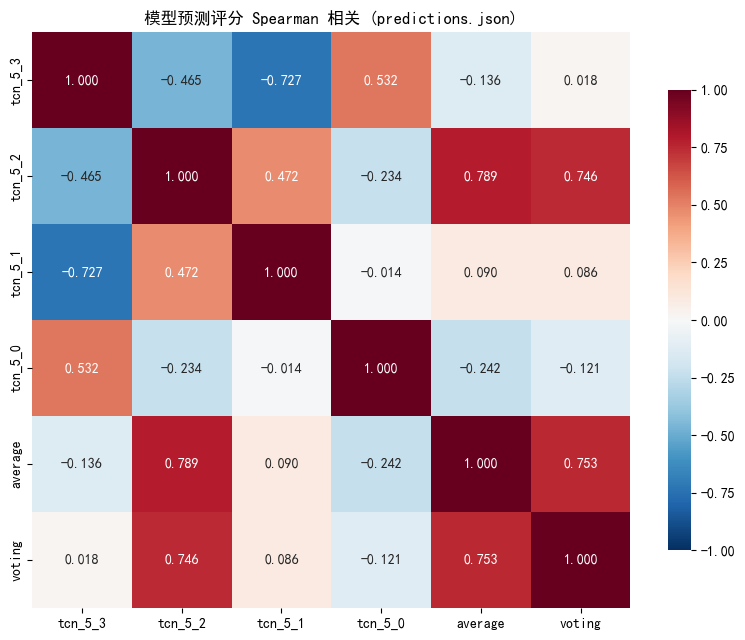


解读: 相关性越低 → 模型越多样 → ensemble 受益越大
若所有模型相关性 > 0.95，融合意义有限


In [23]:
if 'corr_matrix' in dir() and len(corr_matrix) > 0:
    try:
        import seaborn as sns
        fig, ax = plt.subplots(figsize=(8, 6.5))
        sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
                    vmin=-1, vmax=1, center=0, ax=ax, cbar_kws={'shrink': 0.8})
        ax.set_title('模型预测评分 Spearman 相关 (predictions.json)')
        plt.tight_layout()
        plt.show()
    except ImportError:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(len(corr_matrix.columns)))
        ax.set_yticks(range(len(corr_matrix.index)))
        ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(corr_matrix.index, fontsize=8)
        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix.columns)):
                ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}', ha='center', va='center', fontsize=7)
        ax.set_title('模型预测评分 Spearman 相关')
        plt.colorbar(im, shrink=0.8)
        plt.tight_layout()
        plt.show()
    print('\n解读: 相关性越低 → 模型越多样 → ensemble 受益越大')
    print('若所有模型相关性 > 0.95，融合意义有限')
else:
    print('请先计算相关性矩阵')

## 11. ETF 类别分析

按 ETF 名称关键词分类，检验模型在不同类别上的预测能力。


In [24]:
NAMES_FILE = '../etf_data/etf_list_before_2022_74.csv'
if not os.path.exists(NAMES_FILE):
    print(f'未找到 {NAMES_FILE}')
else:
    names_df = pd.read_csv(NAMES_FILE)
    names_df.columns = names_df.columns.str.replace('\ufeff', '')
    name_map = dict(zip(names_df['代码'], names_df['名称']))
    print(f'已加载 {len(name_map)} 个 ETF 名称')

    CATEGORY_RULES = [
        ('跨境', ['纳指', '标普500', '日经', '德国', '香港', '恒生', '恒指', '中概', '教育ETF']),
        ('商品', ['黄金', '白银', '原油', '豆粕', '能源化工']),
        ('宽基', ['300ETF', '500ETF', '1000ETF', '上证ETF', '创业板', '科创']),
        ('科技', ['半导体', '芯片', '人工智能', '软件ETF', '计算机ETF', '大数据', '云计算', '5G', '通信ETF', '机器人', '消费电子']),
        ('新能源', ['光伏', '新汽车', '锂电池', '新能源', '电池ETF', '智能驾驶']),
        ('周期', ['有色', '煤炭', '钢铁', '化工ETF', '稀土', '稀有金属']),
        ('金融', ['证券ETF', '银行ETF', '证券保险', '金融科技']),
        ('消费', ['酒ETF', '食品饮料', '消费ETF', '养殖', '农业', '旅游ETF', '文娱', '游戏ETF', '传媒ETF']),
        ('医药', ['医疗ETF', '医药ETF', '创新药', '医疗器械']),
        ('军工', ['军工龙头', '国防ETF', '军工ETF']),
        ('红利/转债', ['红利', '转债']),
        ('地产', ['地产ETF']),
    ]

    def assign_category(code):
        name = name_map.get(code, '')
        for cat, keywords in CATEGORY_RULES:
            for kw in keywords:
                if kw in name:
                    return cat
        return '其他'

    stock_to_cat = {code: assign_category(code) for code in name_map}
    cat_counts = pd.Series(stock_to_cat).value_counts()
    print('\nETF 类别分布:')
    for cat, cnt in cat_counts.items():
        codes = [c for c, v in stock_to_cat.items() if v == cat]
        names = [name_map[c] for c in codes]
        print(f'  {cat} ({cnt}只): {', '.join(names)}')

已加载 74 个 ETF 名称

ETF 类别分布:
  科技 (12只): 软件ETF嘉实, 半导体, 通信ETF, 机器人, 人工智能ETF易方达, 人工智能, 芯片ETF华夏, 计算机ETF天弘, 大数据, 5GETF, 云计算, 消费电子ETF华夏
  跨境 (11只): 纳指ETF, 标普500, 日经ETF, 德国ETF, 香港证券, 恒指科技, 恒生互联, 恒生医药ETF华夏, 中概互联ETF广发, 恒生中国, 教育ETF
  消费 (9只): 传媒ETF, 游戏ETF华夏, 酒ETF, 消费ETF汇添富, 旅游ETF富国, 文娱ETF, 养殖ETF国泰, 食品饮料, 农业ETF富国
  宽基 (8只): 500ETF, 1000ETF, 300ETF, 上证ETF, 创业板ETF易方达, 创业板50ETF华安, 创业板成长ETF华夏, 科创板50
  周期 (7只): 有色ETF大成, 有色ETF, 化工ETF鹏华, 稀土基金, 稀有金属, 煤炭ETF, 钢铁ETF
  新能源 (6只): 电池ETF广发, 光伏ETF, 新能源, 智能驾驶, 新汽车, 锂电池ETF工银
  商品 (5只): 黄金ETF, 国投白银LOF, 南方原油, 豆粕ETF华夏, 能源化工ETF建信
  医药 (5只): 医疗ETF, 创新药ETF银华, 医药ETF, 医疗器械ETF永赢, 创新药
  金融 (4只): 证券ETF, 金融科技ETF华宝, 银行ETF, 证券保险
  红利/转债 (3只): 转债ETF, 红利低波, 红利ETF
  军工 (3只): 军工龙头, 军工ETF, 国防ETF
  地产 (1只): 地产ETF


In [25]:
if 'stock_to_cat' not in dir() or len(stock_to_cat) == 0 or 'metrics_df' not in dir() or len(metrics_df) == 0 or 'etf' not in dir():
    print('请先运行 ETF 分类单元格')
elif 'metrics_df' not in dir() or len(metrics_df) == 0:
    print('请先运行第6节批量计算')
else:
    from scipy.stats import spearmanr
    best_exp = metrics_df.nlargest(1, 'ic_mean').iloc[0]
    mt, ei = best_exp['model_type'], int(best_exp['exp_idx'])
    print(f'分析模型: {mt}_exp_{ei}')

    vp_file = None
    for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
        model_type = os.path.basename(os.path.normpath(mt_dir))
        parts = model_type.split("_")
        mt_short = parts[1] if len(parts) >= 2 else model_type
        if mt_short == mt:
            tp = os.path.join(mt_dir, f"exp_{ei}", "fold_3", "val_predictions.json")
            if os.path.exists(tp):
                vp_file = tp
                break
    if vp_file is None:
        print('未找到 val_predictions')
    else:
        with open(vp_file) as f:
            vp = json.load(f)

        etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
        etf_sorted['_next_close'] = etf_sorted.groupby('股票代码')['收盘'].shift(-1)
        etf_sorted['_next_open'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
        etf_sorted['fwd_ret'] = (etf_sorted['_next_close'] - etf_sorted['_next_open']) / etf_sorted['_next_open']
        fwd_lookup = etf_sorted[['股票代码', '日期', 'fwd_ret']].dropna()

        all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
        date_to_idx = {d: i for i, d in enumerate(all_dates)}
        idx_to_date = {i: d for d, i in date_to_idx.items()}

        cat_ic = {cat: [] for cat in set(stock_to_cat.values())}
        for d, entries in vp.items():
            dt = pd.to_datetime(d)
            df_day = pd.DataFrame(entries)
            df_day = df_day.rename(columns={'stock_id': '股票代码'})
            df_day['日期'] = dt
            idx = date_to_idx.get(dt)
            if idx is None: continue
            next_dt = idx_to_date.get(idx + 1)
            if next_dt is None: continue
            merged = df_day.merge(
                fwd_lookup[(fwd_lookup['日期'] == next_dt)],
                on=['股票代码', '日期'], how='inner')
            if len(merged) < 3: continue
            merged['category'] = merged['股票代码'].map(stock_to_cat)
            for cat, grp in merged.groupby('category'):
                if len(grp) < 3: continue
                ic, _ = spearmanr(grp['score'], grp['fwd_ret'])
                cat_ic[cat].append(ic)

        cat_results = []
        for cat, ic_list in sorted(cat_ic.items()):
            if len(ic_list) == 0: continue
            ic_arr = np.array(ic_list)
            n_stocks = sum(1 for c in stock_to_cat if stock_to_cat[c] == cat)
            cat_results.append({'类别': cat, 'ETF数量': n_stocks, '有效天数': len(ic_arr),
                                'IC均值': ic_arr.mean(), 'IC>0%': (ic_arr > 0).mean()})
        cat_df = pd.DataFrame(cat_results)
        if len(cat_df) == 0:
            print('无有效类别数据')
        else:
            cat_df['IC>0%'] = cat_df['IC>0%'].map('{:.0%}'.format)
            cat_df['IC均值'] = cat_df['IC均值'].map('{:.4f}'.format)
            display(cat_df)



分析模型: gru_exp_9
无有效类别数据


In [26]:
if 'cat_df' in dir() and len(cat_df) > 0:
    cat_plot = cat_df.copy()
    cat_plot['IC均值'] = pd.to_numeric(cat_plot['IC均值'], errors='coerce')
    cat_plot = cat_plot.dropna(subset=['IC均值']).sort_values('IC均值', ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    colors_bar = ['#2aa054' if v > 0 else '#E24A33' for v in cat_plot['IC均值']]
    ax.barh(range(len(cat_plot)), cat_plot['IC均值'], color=colors_bar, edgecolor='white')
    ax.set_yticks(range(len(cat_plot)))
    ax.set_yticklabels(cat_plot['类别'])
    ax.axvline(x=0, color='gray', ls='--', lw=0.5)
    ax.set_xlabel('IC 均值')
    ax.set_title(f'各类别 IC (最佳模型, fold_3)')
    for i, (_, row) in enumerate(cat_plot.iterrows()):
        ax.text(row['IC均值'] + 0.002 if row['IC均值'] >= 0 else row['IC均值'] - 0.015,
                i, f"n={int(row['有效天数'])}", va='center', fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print('请先计算类别 IC')

请先计算类别 IC


## 12. 跨折一致性

计算 Top-20 实验在所有 4 折上的 IC 均值和标准差，评估模型的时间稳定性。


In [27]:
if 'metrics_df' not in dir() or len(metrics_df) == 0 or 'etf' not in dir():
    print('请先运行第6节批量计算')
else:
    import time
    from scipy.stats import spearmanr
    top20 = metrics_df.nlargest(20, 'ic_mean').reset_index(drop=True)

    etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
    etf_sorted['_next_close'] = etf_sorted.groupby('股票代码')['收盘'].shift(-1)
    etf_sorted['_next_open'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
    etf_sorted['fwd_ret'] = (etf_sorted['_next_close'] - etf_sorted['_next_open']) / etf_sorted['_next_open']
    fwd_lookup = etf_sorted[['股票代码', '日期', 'fwd_ret']].dropna()
    all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    idx_to_date = {i: d for d, i in date_to_idx.items()}

    fold_rows = []
    t0 = time.time()
    for _, row in top20.iterrows():
        mt = row['model_type']
        ei = int(row['exp_idx'])
        exp_dir = None
        for mt_dir in sorted(glob.glob(f"{TSCV_DIR}/*/")):
            model_type = os.path.basename(os.path.normpath(mt_dir))
            parts = model_type.split("_")
            mt_short = parts[1] if len(parts) >= 2 else model_type
            if mt_short == mt:
                ed = os.path.join(mt_dir, f"exp_{ei}")
                if os.path.exists(ed):
                    exp_dir = ed
                    break
        if exp_dir is None: continue

        fold_ics = []
        for fi in range(4):
            vp_file = os.path.join(exp_dir, f'fold_{fi}', 'val_predictions.json')
            if not os.path.exists(vp_file): continue
            with open(vp_file) as f: vp = json.load(f)
            rows = []
            for d, entries in vp.items():
                for e in entries:
                    rows.append({'date': pd.to_datetime(d), 'stock_id': e['stock_id'], 'score': e['score']})
            fd = pd.DataFrame(rows)
            fd['_date_idx'] = fd['date'].map(date_to_idx)
            fd['_next_idx'] = fd['_date_idx'] + 1
            fd['_next_date'] = fd['_next_idx'].map(idx_to_date)
            fd = fd.dropna(subset=['_next_date'])
            merged = fd.merge(fwd_lookup, left_on=['stock_id', '_next_date'],
                              right_on=['股票代码', '日期'], how='inner')
            if len(merged) < 5: continue
            ic_vals = merged.groupby('date').apply(
                lambda g: spearmanr(g['score'], g['fwd_ret'])[0], include_groups=False)
            fold_ics.append(ic_vals.mean())

        if len(fold_ics) >= 2:
            fold_rows.append({'model_type': mt, 'exp_idx': ei,
                             'folds': len(fold_ics),
                             'ic_mean': np.mean(fold_ics),
                             'ic_std': np.std(fold_ics),
                             'consistency': np.mean(fold_ics) / np.std(fold_ics) if np.std(fold_ics) > 0 else 0})

    consistency_df = pd.DataFrame(fold_rows)
    consistency_df = consistency_df.sort_values('consistency', ascending=False).reset_index(drop=True)
    consistency_df.index = range(1, len(consistency_df) + 1)
    print(f'跨折一致性 (IC均值/IC标准差, 越高越稳定): ({time.time()-t0:.0f}s)')
    display(consistency_df.round(4))



跨折一致性 (IC均值/IC标准差, 越高越稳定): (321s)


,model_type,exp_idx,folds,ic_mean,ic_std,consistency
1,tcn,44,4,0.0155,0.0133,1.1638
2,dlinear,10,4,0.0277,0.0260,1.0679
3,dlinear,2,4,0.0187,0.0184,1.0157
4,tcn,30,4,0.0118,0.0117,1.0123
5,dlinear,0,4,0.0251,0.0259,0.9712
6,dlinear,19,4,0.0218,0.0226,0.9625
7,gru,17,4,0.0092,0.0137,0.6743
8,gru,9,4,0.0153,0.0244,0.6283
9,gru,1,4,0.0096,0.0177,0.5412
10,gru,3,4,0.0091,0.0175,0.5207


## 13. 综合模型选择

综合 TSCV 回测指标（cv_score）和验证集信号指标（IC, Spread, IR, 跨折一致性），加权排序。
权重可调，默认配置见下方。


In [28]:
if 'df' not in dir() or len(df) == 0:
    print('请先运行第1部分加载 TSCV 结果')
elif 'metrics_df' not in dir() or len(metrics_df) == 0:
    print('请先运行第6节批量计算')
else:
    # 合并全部指标
    merged = df.merge(metrics_df, on=['model_type', 'exp_idx'], how='left')
    merged = merged.dropna(subset=['cv_score', 'ic_mean'])

    # 分位数评分：越高越好
    higher_better = [
        'cv_score', 'mean_sharpe', 'mean_sortino', 'mean_win_rate',
        'fold_3_sharpe', 'fold_3_win_rate', 'fold_3_sortino',
        'ic_mean', 'ir', 'ic_pos', 'spread_mean', 'spread_pos',
    ]
    lower_better = [
        'std_sharpe', 'mean_max_dd', 'ic_std',
    ]

    available = []
    for col in higher_better:
        if col in merged.columns and merged[col].notna().sum() > 5:
            merged[f'q_{col}'] = merged[col].rank(pct=True)
            available.append(f'q_{col}')
    for col in lower_better:
        if col in merged.columns and merged[col].notna().sum() > 5:
            merged[f'q_{col}'] = 1 - merged[col].rank(pct=True)
            available.append(f'q_{col}')

    merged['综合评分'] = merged[available].mean(axis=1)
    n_metrics = len(available)

    final = merged.sort_values('综合评分', ascending=False).reset_index(drop=True)
    final['排名'] = range(1, len(final) + 1)

    # 显示列：排名 + 核心信息 + 全部指标
    display_cols = ['排名', 'model_type', 'exp_idx', '综合评分']
    all_metric_cols = [
        'cv_score', 'mean_sharpe', 'std_sharpe',
        'fold_3_sharpe', 'fold_3_win_rate', 'fold_3_sortino',
        'ic_mean', 'ir', 'ic_pos', 'ic_std',
        'spread_mean', 'spread_pos',
        'mean_sortino', 'mean_win_rate', 'mean_max_dd',
    ]
    for col in all_metric_cols:
        if col in final.columns:
            display_cols.append(col)

    # Top-20
    display_df = final.head(20)[display_cols].copy()
    display_df['综合评分'] = display_df['综合评分'].map('{:.4f}'.format)

    # 格式美化
    fmt_cols = {
        'cv_score': '{:.2f}', 'mean_sharpe': '{:.2f}', 'std_sharpe': '{:.2f}',
        'fold_3_sharpe': '{:.2f}', 'fold_3_win_rate': '{:.2%}', 'fold_3_sortino': '{:.2f}',
        'ic_mean': '{:.4f}', 'ir': '{:.2f}', 'ic_pos': '{:.0%}', 'ic_std': '{:.4f}',
        'spread_mean': '{:.4f}', 'spread_pos': '{:.0%}',
        'mean_sortino': '{:.2f}', 'mean_win_rate': '{:.2%}', 'mean_max_dd': '{:.2f}',
    }
    for col, fmt in fmt_cols.items():
        if col in display_df.columns:
            try:
                display_df[col] = display_df[col].map(fmt.format)
            except:
                pass

    print(f'综合排名 (共 {len(final)} 个实验, {n_metrics} 个指标等权分位数平均)')
    print('越高越好指标:', ', '.join(higher_better[:6]) + '...')
    print('越低越好指标:', ', '.join(lower_better))

    # 带背景色渐变的排名表
    styled = display_df.style\
        .background_gradient(subset=['综合评分'], cmap='RdYlGn')\
        .set_properties(subset=['排名'], **{'text-align': 'center'})\
        .set_caption('Top-20 模型综合排名')
    display(styled)

    # 简表：Top-5
    print('\nTop-5 推荐:')
    summary = final.head(5)[['model_type', 'exp_idx', '综合评分',
                             'cv_score', 'fold_3_sharpe', 'ic_mean', 'spread_mean']]
    summary['综合评分'] = summary['综合评分'].map('{:.4f}'.format)
    summary['cv_score'] = summary['cv_score'].map('{:.2f}'.format)
    summary['fold_3_sharpe'] = summary['fold_3_sharpe'].map('{:.2f}'.format)
    summary['ic_mean'] = summary['ic_mean'].map('{:.4f}'.format)
    summary['spread_mean'] = summary['spread_mean'].map('{:.4f}'.format)
    display(summary)


综合排名 (共 94 个实验, 15 个指标等权分位数平均)
越高越好指标: cv_score, mean_sharpe, mean_sortino, mean_win_rate, fold_3_sharpe, fold_3_win_rate...
越低越好指标: std_sharpe, mean_max_dd, ic_std


,排名,model_type,exp_idx,综合评分,cv_score,mean_sharpe,std_sharpe,fold_3_sharpe,fold_3_win_rate,fold_3_sortino,ic_mean,ir,ic_pos,ic_std,spread_mean,spread_pos,mean_sortino,mean_win_rate,mean_max_dd
0,1,gru,10,0.8493,1.89,2.45,0.56,2.99,77.19%,5.64,0.0323,0.22,59%,0.1496,0.0049,61%,3.97,81.25%,8.19
1,2,tcn,43,0.8092,2.53,2.90,0.37,2.50,61.33%,4.79,0.0309,0.22,54%,0.1402,0.0024,61%,4.73,72.69%,7.80
2,3,tcn,54,0.7911,2.07,2.51,0.44,2.69,43.14%,4.11,0.0277,0.22,61%,0.1288,0.0037,68%,3.78,67.93%,6.49
3,4,tcn,11,0.7794,1.48,2.68,1.20,2.73,71.60%,4.01,0.0282,0.23,61%,0.1205,0.0037,59%,4.23,77.82%,11.81
4,5,tcn,28,0.7787,1.98,2.27,0.29,2.24,43.75%,4.19,0.0371,0.24,62%,0.1552,0.0028,62%,3.98,74.88%,10.19
5,6,tcn,5,0.7741,2.19,2.38,0.19,2.35,56.92%,3.89,0.0175,0.14,55%,0.1207,0.0036,61%,3.98,75.90%,6.90
6,7,tcn,35,0.7730,1.72,2.16,0.43,2.30,63.46%,4.17,0.0272,0.22,55%,0.1215,0.0042,68%,3.32,73.01%,9.42
7,8,tcn,49,0.7645,1.99,2.31,0.32,2.22,58.97%,3.66,0.0245,0.20,59%,0.1212,0.0028,58%,3.32,73.95%,7.97
8,9,gru,14,0.7447,2.07,2.48,0.41,2.30,57.38%,4.13,0.0307,0.19,58%,0.1642,0.0028,58%,4.07,71.69%,9.21
9,10,tcn,45,0.7358,1.93,2.48,0.55,2.54,51.35%,4.67,0.0271,0.22,56%,0.1256,0.0022,54%,3.78,72.37%,7.68



Top-5 推荐:


,model_type,exp_idx,综合评分,cv_score,fold_3_sharpe,ic_mean,spread_mean
0,gru,10,0.8493,1.89,2.99,0.0323,0.0049
1,tcn,43,0.8092,2.53,2.50,0.0309,0.0024
2,tcn,54,0.7911,2.07,2.69,0.0277,0.0037
3,tcn,11,0.7794,1.48,2.73,0.0282,0.0037
4,tcn,28,0.7787,1.98,2.24,0.0371,0.0028


In [ ]:
# ============================================================
# 排列检验：模型信号 vs 随机排序
# 对每个代表性实验，将 score 随机打乱 500 次，在 4 个维度上
# 对比模型是否显著优于随机:
#   1. IC — 排序能力
#   2. Top-3 平均收益 — 选股绝对收益
#   3. Spread (Top3-Bot3) — 多空收益
#   4. Spread Sharpe — 多空风险调整收益
# ============================================================
if 'merged' not in dir() or 'final' not in dir() or 'TSCV_DIR' not in dir():
    print('请先运行综合排名单元格')
elif 'etf' not in dir():
    print('请先加载 ETF 数据')
else:
    import time
    from scipy.stats import spearmanr
    np.random.seed(42)
    n_perm = 500

    # 选取代表性实验
    candidates = []
    for _, r in final.head(5).iterrows():
        candidates.append((r['model_type'], r['exp_idx']))
    mid = len(final) // 2
    for _, r in final.iloc[mid:mid+2].iterrows():
        candidates.append((r['model_type'], r['exp_idx']))
    for _, r in final.tail(2).iterrows():
        candidates.append((r['model_type'], r['exp_idx']))
    deploy_check = [('tcn', 5), ('gru', 16), ('gru', 10), ('tcn', 28), ('dlinear', 17)]
    for mt, ei in deploy_check:
        if (mt, ei) not in candidates:
            candidates.append((mt, ei))

    seen = set()
    unique_candidates = []
    for mt, ei in candidates:
        key = f'{mt}_{ei}'
        if key not in seen:
            seen.add(key)
            unique_candidates.append((mt, ei))

    print(f'排列检验: {len(unique_candidates)} 个实验 × {n_perm} 次随机, '
          f'共 {len(unique_candidates)*n_perm:,} 次模拟...')

    # 构建 forward return lookup
    etf_sorted = etf.sort_values(['股票代码', '日期']).copy()
    etf_sorted['_next_close'] = etf_sorted.groupby('股票代码')['收盘'].shift(-1)
    etf_sorted['_next_open'] = etf_sorted.groupby('股票代码')['开盘'].shift(-1)
    etf_sorted['fwd_ret'] = (etf_sorted['_next_close'] - etf_sorted['_next_open']) / etf_sorted['_next_open']
    all_dates = sorted(pd.to_datetime(etf['日期'].unique()))
    date_to_idx = {d: i for i, d in enumerate(all_dates)}
    idx_to_date = {i: d for d, i in date_to_idx.items()}

    # 构建 model_type 短名 → 目录名映射
    mt_dir_map = {}
    for mt_dir in sorted(glob.glob(f'{TSCV_DIR}/*/')):
        full = os.path.basename(os.path.normpath(mt_dir))
        parts = full.split('_')
        short = parts[1] if len(parts) >= 2 else full
        mt_dir_map[short] = full

    rows = []
    t0 = time.time()

    for mt, ei in unique_candidates:
        full_dir = mt_dir_map.get(mt)
        if full_dir is None:
            continue
        vp_file = os.path.join(TSCV_DIR, full_dir, f'exp_{ei}', 'fold_3', 'val_predictions.json')
        if not os.path.exists(vp_file):
            continue
        with open(vp_file) as f:
            vp = json.load(f)

        # 构建每日数据
        day_data = []
        for d_str, entries in vp.items():
            dt = pd.to_datetime(d_str)
            idx = date_to_idx.get(dt)
            if idx is None:
                continue
            next_dt = idx_to_date.get(idx + 1)
            if next_dt is None:
                continue
            scores = {e['stock_id']: e['score'] for e in entries}
            fwd_data = fwd_lookup[fwd_lookup['日期'] == next_dt]
            if len(fwd_data) < 10:
                continue
            common = [s for s in scores if s in fwd_data['股票代码'].values]
            if len(common) < 10:
                continue
            y = fwd_data.set_index('股票代码').loc[common, 'fwd_ret'].values
            x = np.array([scores[s] for s in common])
            day_data.append((x, y))
        n_days = len(day_data)
        if n_days < 10:
            continue

        # ---- 真实值 ----
        real_ics, real_spreads, real_top3s = [], [], []
        for x, y in day_data:
            order = np.argsort(x)
            ic, _ = spearmanr(x, y)
            real_ics.append(ic)
            t3 = y[order[-3:]].mean()
            b3 = y[order[:3]].mean()
            real_top3s.append(t3)
            real_spreads.append(t3 - b3)
        real_ic = np.mean(real_ics)
        real_top3 = np.mean(real_top3s)
        real_spread = np.mean(real_spreads)
        real_spread_sharpe = np.mean(real_spreads) / (np.std(real_spreads) + 1e-8)

        # ---- 随机排列 ----
        perm_ics, perm_spreads = [], []
        perm_top3s, perm_spread_sharpes = [], []
        for _ in range(n_perm):
            d_ics, d_spreads, d_top3s = [], [], []
            for x, y in day_data:
                xs = np.random.permutation(x)
                order = np.argsort(xs)
                ic, _ = spearmanr(xs, y)
                d_ics.append(ic)
                t3 = y[order[-3:]].mean()
                d_top3s.append(t3)
                d_spreads.append(t3 - y[order[:3]].mean())
            perm_ics.append(np.mean(d_ics))
            perm_top3s.append(np.mean(d_top3s))
            perm_spreads.append(np.mean(d_spreads))
            perm_spread_sharpes.append(np.mean(d_spreads) / (np.std(d_spreads) + 1e-8))

        perm_ics = np.array(perm_ics)
        perm_top3s = np.array(perm_top3s)
        perm_spreads = np.array(perm_spreads)
        perm_spread_sharpes = np.array(perm_spread_sharpes)

        def _cmp(real_arr, perm_arr):
            """返回 (p值, 是否优于95%随机)"""
            p = (np.sum(perm_arr >= np.mean(real_arr)) + 1) / (len(perm_arr) + 1)
            better = np.mean(real_arr) > np.percentile(perm_arr, 95)
            return p, better

        ic_p, ic_ok = _cmp(real_ics, perm_ics)
        top3_p, top3_ok = _cmp(real_top3s, perm_top3s)
        spread_p, spread_ok = _cmp(real_spreads, perm_spreads)
        ss_p, ss_ok = _cmp(real_spreads, perm_spread_sharpes)  # spread sharpe

        rows.append({
            'model_type': mt, 'exp_idx': ei, 'n_days': n_days,
            'ic_real': real_ic, 'ic_med': np.median(perm_ics),
            'ic_p95': float(np.percentile(perm_ics, 95)),
            'ic_p': ic_p, 'ic_ok': ic_ok,
            'top3_real': real_top3, 'top3_med': float(np.median(perm_top3s)),
            'top3_p95': float(np.percentile(perm_top3s, 95)),
            'top3_p': top3_p, 'top3_ok': top3_ok,
            'spread_real': real_spread, 'spread_med': float(np.median(perm_spreads)),
            'spread_p95': float(np.percentile(perm_spreads, 95)),
            'spread_p': spread_p, 'spread_ok': spread_ok,
            'ss_real': real_spread_sharpe, 'ss_med': float(np.median(perm_spread_sharpes)),
            'ss_p95': float(np.percentile(perm_spread_sharpes, 95)),
            'ss_p': ss_p, 'ss_ok': ss_ok,
        })

    perm_df = pd.DataFrame(rows)
    elapsed = time.time() - t0
    print(f'完成: {elapsed:.0f}s')

    # ---- 结果表格 ----
    print('\n排列检验 (500次随机, 显著性水平 α=0.05):')
    print('✅ = 优于95%随机 | ⚠️ = 高于中位但低于P95 | ❌ = 不如随机中位数')
    print()
    header = f'{"实验":<14} {"IC":>7} {"Top-3收益":>10} {"Spread":>9} {"SpreadSharpe":>14}'
    print(header)
    print('-' * len(header))
    for _, r in perm_df.iterrows():
        def _flag(p, ok):
            return '✅' if ok else ('⚠️' if p < 0.50 else '❌')
        tag = f'{r["model_type"]}_{r["exp_idx"]}'
        print(f'{tag:<14} {_flag(r["ic_p"], r["ic_ok"]):>7} '
              f'{_flag(r["top3_p"], r["top3_ok"]):>10} '
              f'{_flag(r["spread_p"], r["spread_ok"]):>9} '
              f'{_flag(r["ss_p"], r["ss_ok"]):>14}')

    # 统计摘要
    print()
    n_all = len(perm_df)
    print(f'总实验: {n_all}')
    print(f'IC优于随机:    {sum(perm_df["ic_ok"])}/{n_all} '
          f'(优于中位: {sum(perm_df["ic_p"] < 0.5)}/{n_all})')
    print(f'Top-3收益优于随机: {sum(perm_df["top3_ok"])}/{n_all} '
          f'(优于中位: {sum(perm_df["top3_p"] < 0.5)}/{n_all})')
    print(f'Spread优于随机: {sum(perm_df["spread_ok"])}/{n_all}')
    print(f'SpreadSharpe优于随机: {sum(perm_df["ss_ok"])}/{n_all}')

    # ---- 四维散点图 ----
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    titles = ['IC', 'Top-3 平均收益', 'Spread (Top3-Bot3)', 'Spread Sharpe']
    val_pairs = [('ic_real', 'ic_med', 'ic_p95'),
                 ('top3_real', 'top3_med', 'top3_p95'),
                 ('spread_real', 'spread_med', 'spread_p95'),
                 ('ss_real', 'ss_med', 'ss_p95')]
    colors_p = {'tcn': '#348ABD', 'dlinear': '#E24A33', 'gru': '#988ED5'}
    for ax, title, (vr, vm, vp95) in zip(axes.flat, titles, val_pairs):
        for _, r in perm_df.iterrows():
            c = colors_p.get(r['model_type'], '#888')
            ax.scatter(r[vr], 0, c=c, s=60, zorder=5)
            ax.plot([r[vm], r[vp95]], [0, 0], c=c, lw=4, alpha=0.5)
            ax.scatter(r[vm], 0, c=c, s=20, marker='|')
        ax.axvline(0, color='gray', ls='--', lw=0.5)
        ax.set_yticks([])
        ax.set_title(title)
        ax.grid(True, alpha=0.3, axis='x')
    plt.suptitle('模型表现 vs 随机分布 (点=真实值, 线=中位数→P95)', fontsize=13)
    plt.tight_layout()
    plt.show()
